# Credit Card Fraud Detection — Model Evaluation, Interpretability & Serving - Parte 4

In questo notebook viene affrontato il problema della rilevazione di frodi su transazioni con carta di credito,
utilizzando il *Credit Card Transactions Fraud Detection Dataset*.

Il contesto simulato è quello di una banca o di un emittente di carte di credito che deve monitorare un elevato volume di transazioni in tempo quasi-reale, individuando tempestivamente quelle potenzialmente fraudolente.
Il problema presenta due caratteristiche fondamentali:

- **Forte sbilanciamento delle classi**: le transazioni fraudolente rappresentano una percentuale molto ridotta del totale.
- **Asimmetria dei costi di errore**: una frode non intercettata genera una perdita economica significativa, mentre il blocco errato di una transazione legittima comporta costi operativi e un impatto sull’esperienza del cliente.

Per questo motivo, l’obiettivo non è massimizzare l’accuratezza complessiva, ma costruire un modello che ottimizzi il compromesso tra intercettazione delle frodi e contenimento dei falsi allarmi, in funzione di considerazioni di business.

La quarta parte del notebook è dedicata:
- Test Modelli salvati e valutazione finale
- Interpretabilità e analisi errori
- Pipeline di serving

In [83]:
#import delle librerie necessarie per:

#Elaborazione dati e grafici
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from itertools import product
import kagglehub

#Costruzione degli algoritmi e aggiunta metriche per la valutazione
import joblib #salvataggio modelli
import shap
from xgboost import XGBClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, precision_recall_curve, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

pd.options.display.float_format = '{:.4f}'.format #per visualizzare la tabella in maniera più leggibile, altrimenti vedremmo i numeri indicati con notazione scientifica

## Riporto dal secondo notebook solo le funzioni per la costruzione della pipeline, alcune sono state modificate per bloccare il salvataggio degli stati

In [84]:
# Download ultima versione
path = kagglehub.dataset_download("kartik2112/fraud-detection")

print("Path to dataset files:", path)

df_train = pd.read_csv(path+"/fraudTrain.csv")
df_test  = pd.read_csv(path+"/fraudTest.csv")
df_test = df_test.sort_values("trans_date_trans_time").reset_index(drop=True) # Ordinato temporalmente per successiva analisi errori dei modelli

print("Shape dataset di Train ", df_train.shape)

Path to dataset files: C:\Users\orenj\.cache\kagglehub\datasets\kartik2112\fraud-detection\versions\1
Shape dataset di Train  (1296675, 23)


In [85]:
## Feature numeriche di base
def add_base_num_features(df):
  df["log_amt"] = np.log1p(df["amt"].clip(lower=0)) #clip a 0 per evitare problemi con eventuali valori anomali futuri
  df["log_city_pop"] = np.log1p(df["city_pop"].clip(lower=0))
  return df

In [86]:
## Feature Temporali
temporal_static = ["hour", "dayofweek", "month"]
temporal_cyclic = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]

def add_temporal_features(df):
  df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"])

  df = df.sort_values("trans_date_trans_time").reset_index(drop=True) #importante anche per le trasformazioni future

  df["hour"] = df["trans_date_trans_time"].dt.hour
  df["dayofweek"] = df["trans_date_trans_time"].dt.dayofweek
  df["is_weekend"] = df["dayofweek"].isin([5,6]).astype(int)
  df["month"] = df["trans_date_trans_time"].dt.month
  df["is_night"] = ((df["hour"] >= 21) | (df["hour"] <= 4)).astype(int)

  #Introduciamo Feature cicliche da utilizzare in via sperimentale
  # --- Ciclicità ora ---
  df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
  df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

  # --- Ciclicità giorno della settimana ---
  df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
  df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

  # --- Ciclicità mese ---
  df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
  df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)
  return df

In [87]:
## Distanza cliente–merchant (Haversine)

def haversine(df):
  R = 6371

  lat1 = df["lat"]
  lon1 = df["long"]
  lat2 = df["merch_lat"]
  lon2 = df["merch_long"]

  lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
  dlat = lat2 - lat1
  dlon = lon2 - lon1
  a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
  df["cust_merch_km"] = 2 * R * np.arcsin(np.sqrt(a))

  return df

In [228]:
## Feature storiche cliente (cc_num)

def add_customer_history(df, alpha=50, prior=None, stats=None):

  if prior is None:
      prior = df["is_fraud"].mean()

  if stats is None:
      stats = {}

  txn, fraud, rate, delta = [], [], [], []

  for r in df.itertuples(index=False):
      cc = r.cc_num
      # y = r.is_fraud non presente
      t = r.trans_date_trans_time

      n_txn, n_fraud, last_t = stats.get(cc, (0, 0, None))

      txn.append(n_txn)
      fraud.append(n_fraud)
      rate.append((n_fraud + alpha*prior)/(n_txn + alpha))
      delta.append(-1 if last_t is None else (t-last_t).total_seconds())

      #stats[cc] = (n_txn, n_fraud, t) #aggiornamento bloccato, l'aggiornamento portava ad un peggioramento delle performance, dettagli nel commento che segue

  df["cust_txn_count_so_far"] = txn
  df["cust_fraud_count_so_far"] = fraud
  df["cust_fraud_rate_so_far_smoothed"] = rate
  df["cust_delta_prev_sec"] = delta

  return df, stats

In [254]:
#Nuovo Merchant per cliente - modificato per test

def add_new_merchant_feature(df, seen=None):
    """
    Feature leakage-safe:
    is_new_merchant_for_customer = 1 se il cliente non ha mai transato
    con quel merchant prima di questa transazione
    """
    if seen is None:
      seen = {}  # cc_num -> set di merchant già visti

    is_new = []

    for r in df.itertuples(index=False):
        cc = r.cc_num
        merch = r.merchant

        if cc not in seen:  # non aggiorniamo il dataset di test
            flag = 1 #nuovo cliente no storico
            is_new.append(flag)

        else :
            # nuovo merchant?
            flag = int(merch not in seen[cc])
            is_new.append(flag)

        #seen[cc].add(merch)

    df["new_merchant_for_customer"] = is_new

    return df, seen

Durante la fase di test, le feature storiche supervisionate (conteggi e tassi di rischio smoothed) sono state calcolate rispetto allo stato congelato al termine della validation, al fine di evitare qualsiasi forma di leakage legata all’uso delle etichette.

Durante la fase di test, si è osservato che l’aggiornamento dinamico della feature di new_merchant_for_customer e cust_delta_prev_sec, pur essendo corretto dal punto di vista operativo, altera significativamente la distribuzione delle probabilità predette rispetto a quella osservata in fase di validazione.
Poiché la soglia decisionale è stata ottimizzata sulle probabilità generate in validazione, tale cambiamento rende la soglia sub-ottimale e peggiora il costo complessivo.
Per garantire coerenza metodologica e una valutazione imparziale dei modelli, le feature storiche sono quindi mantenute congelate allo stato di fine validation.

In [255]:
## Risk score smoothed (merchant / job / zip / city)
r_cols = ["merchant", "job", "zip", "city"]

def add_risk_score(df, cols, alpha=300, prior=None, stats_map=None):

  """
  Risk score smoothed incrementale (leakage-safe).
  Se prior non è fornito, usa il fraud rate globale del df passato.
  """

  if prior is None:
      prior = df["is_fraud"].mean()

  if stats_map is None:
      stats_map = {c: {} for c in cols}

  for col in cols:
    stats = stats_map[col]

    score, count = [], []

    for r in df.itertuples(index=False):
        key = getattr(r, col)
        #y = r.is_fraud non presente in test


        n_txn, n_fraud = stats.get(key, (0, 0))

        score.append((n_fraud + alpha*prior)/(n_txn + alpha))
        count.append(n_txn)

        #stats[key] = (n_txn+1, n_fraud+int(y)) aggiornamento bloccato

    df[f"{col}_risk_score_smoothed"] = score
    df[f"{col}_txn_count_so_far"] = count
    #stats_map[col] = stats aggiornamento bloccato

  return df, stats_map

In [256]:
## Age da dob (leakage-safe)

def add_age_feature(df):
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce") #così da trasformare in NaT eventuali valori anomali

    age_years = (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25
    df["age"] = age_years

    # pulizia valori impossibili / missing
    df.loc[(df["age"] < 0) | (df["age"] > 120), "age"] = np.nan

    if df["age"].isnull().sum() > 0:
        print(f"Warning: {df['age'].isnull().sum()} age values are missing")

    return df

In [257]:
## One-Hot Encoding

ohe_cols = ["category", "state", "gender"]
'''
def get_encoder(df, ohe_cols): #solo su train
  encoder = OneHotEncoder(handle_unknown="ignore",drop="if_binary", sparse_output=False)
  encoder = encoder.fit(df[ohe_cols])
  return encoder
'''
def one_hot_encoding(df, ohe_cols, encoder): #train, validation e test
  ohe = encoder.transform(df[ohe_cols])

  ohe_df = pd.DataFrame(
    ohe,
    columns=encoder.get_feature_names_out(ohe_cols),
    index=df.index
    )

  df_f = pd.concat([df.drop(columns=ohe_cols), ohe_df], axis=1)

  return df_f

In [258]:
#questa funzione non viene utilizzata
'''def temporal_train_val_split(df, date_col="trans_date_trans_time", val_months=3):
    df = df.sort_values(date_col).reset_index(drop=True)
    cutoff = df[date_col].max() - pd.DateOffset(months=val_months) #data di cutoff ultima data - mesi indicati
    df_train = df[df[date_col] < cutoff].copy()
    df_val   = df[df[date_col] >= cutoff].copy()

    return df_train, df_val, cutoff'''

'def temporal_train_val_split(df, date_col="trans_date_trans_time", val_months=3):\n    df = df.sort_values(date_col).reset_index(drop=True)\n    cutoff = df[date_col].max() - pd.DateOffset(months=val_months) #data di cutoff ultima data - mesi indicati\n    df_train = df[df[date_col] < cutoff].copy()\n    df_val   = df[df[date_col] >= cutoff].copy()\n\n    return df_train, df_val, cutoff'

In [259]:
def drop_features(df):
  drop_cols = [
    "Unnamed: 0",
    "trans_date_trans_time",
    "cc_num", "dob",
    "first", "last", "street",
    "merchant", "job", "city", "zip",
    "trans_num", "unix_time",
    "lat", "long", "merch_lat", "merch_long",
    "amt", "city_pop"]

  df = df.drop(columns=drop_cols)

  return df

In [260]:
## Ottimizzazione spazio occupato dalle feature per maggiore velocità in addestramento
def optimize_dtypes(df):

    # BINARY
    binary_cols = [
        "is_weekend", "is_night",
        "new_merchant_for_customer", "gender_M"
    ]
    binary_cols += [c for c in df.columns if c.startswith("category_")]
    binary_cols += [c for c in df.columns if c.startswith("state_")]

    for c in binary_cols:
        if c in df.columns:
            df[c] = df[c].astype("uint8")

    # SMALL INTS
    for c in ["hour", "dayofweek", "month"]:
        if c in df.columns:
            df[c] = df[c].astype("int8")

    # COUNTS
    count_cols = [
        "cust_txn_count_so_far",
        "cust_fraud_count_so_far",
        "merchant_txn_count_so_far",
        "job_txn_count_so_far",
        "zip_txn_count_so_far",
        "city_txn_count_so_far"
    ]
    for c in count_cols:
        if c in df.columns:
            df[c] = df[c].astype("int32")

    # FLOATS
    float_cols = [
        "log_amt","log_city_pop","cust_merch_km","age",
        "cust_delta_prev_sec","cust_fraud_rate_so_far_smoothed",
        "merchant_risk_score_smoothed","job_risk_score_smoothed",
        "zip_risk_score_smoothed","city_risk_score_smoothed",
        "hour_sin","hour_cos","dow_sin","dow_cos",
        "month_sin","month_cos"
    ]
    for c in float_cols:
        if c in df.columns:
            df[c] = df[c].astype("float32")

    return df


In [261]:
''' Appunto qtà/type feature finali
uint8      70 (69 senza is_fraud)
float32    16
int32       6
int8        3
Name: count, dtype: int64
'''

' Appunto qtà/type feature finali\nuint8      70 (69 senza is_fraud)\nfloat32    16\nint32       6\nint8        3\nName: count, dtype: int64\n'

In [262]:
## Flow per trasformazione dataset di test (leakage-safe)

def preprocessing_test(df_raw):
    enc_prior_load = joblib.load("encoder_prior_stats.joblib") # caricamento encoder per ohe e prior

    encoder_load = enc_prior_load["oh_encoder"]
    prior_load = enc_prior_load["prior"]
    seen_state_load = enc_prior_load["seen_state"]
    cust_stats_load = enc_prior_load["cust_stats"]
    risk_stats_load = enc_prior_load["risk_stats"]
    q_load = enc_prior_load["quantile"]

    # 0) copia + pulizia iniziale
    #print(f"Ci sono {df_raw.duplicated().sum()} righe duplicate")

    df_raw = df_raw.drop_duplicates().reset_index(drop=True)

    # cast preventivo delle colonne ad alta cardinalità
    for col in ["merchant", "job", "zip", "city"]:
      df_raw[col] = df_raw[col].astype(str)

    # 1) feature temporali + sort
    df_raw = add_temporal_features(df_raw)  # datetime + sort interno

    if df_raw.shape[0] > 1:
        print(f"Dataset - Inizio: {df_raw['trans_date_trans_time'].min()} - Fine: {df_raw['trans_date_trans_time'].max()}")
    else:
        print(f"Timestamp: {df_raw.loc[0,'trans_date_trans_time']}")

    # 2) feature row-wise (OK farle prima dello split)
    df_raw = add_base_num_features(df_raw)
    df_raw = haversine(df_raw)
    df_raw = add_age_feature(df_raw)

    # 3)Split temporale non necessario per test

    # prior SOLO su train (buona pratica per evitare minimo leakage) - caricato da addestramento
    prior = prior_load
    seen_state = seen_state_load
    cust_stats = cust_stats_load
    risk_stats = risk_stats_load

    # 4) feature "new merchant for customer" (freeze state - test)
    df_raw, seen_state = add_new_merchant_feature(df_raw, seen=seen_state)

    # 5) feature storiche cliente (freeze state - test)
    df_raw, cust_stats = add_customer_history(df_raw, alpha=50, prior=prior, stats=cust_stats)


    # 6) risk score smoothed su colonne ad alta cardinalità (freeze state - test)
    risk_cols = ["merchant", "job", "zip", "city"]
    df_raw, risk_stats = add_risk_score(df_raw, cols=risk_cols, alpha=300, prior=prior, stats_map=risk_stats)

    # 7) OHE: fit su train, transform su train+val (evita problemi di categorie future)
    ohe_cols = ["category", "state", "gender"]
    encoder = encoder_load

    df_raw = one_hot_encoding(df_raw, ohe_cols, encoder)

    # 8) drop colonne raw / non usate
    df_final  = drop_features(df_raw)

    # 9) clipping: soglie calcolate su train e applicate anche a val
    q = q_load
    df_final["cust_delta_prev_sec"]  = df_final["cust_delta_prev_sec"].clip(upper=q)

    # 10) ottimizazione memoria occupata
    df_final = optimize_dtypes(df_final)

    return df_final

In [263]:
#ricarica preprocessor
proc_loader = joblib.load("preprocessor_v1.joblib")

preprocessor = proc_loader["preprocessor"]
num_scaled_features = proc_loader["num_scaled_features"]
num_not_scaled = proc_loader["num_not_scaled"]
print(num_scaled_features, len(num_scaled_features)) #per verifica
print(num_not_scaled, len(num_not_scaled))

['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'log_amt', 'log_city_pop', 'cust_merch_km', 'age', 'cust_txn_count_so_far', 'cust_fraud_count_so_far', 'cust_fraud_rate_so_far_smoothed', 'cust_delta_prev_sec', 'merchant_risk_score_smoothed', 'merchant_txn_count_so_far', 'job_risk_score_smoothed', 'job_txn_count_so_far', 'zip_risk_score_smoothed', 'zip_txn_count_so_far', 'city_risk_score_smoothed', 'city_txn_count_so_far'] 22
['hour', 'dayofweek', 'month', 'is_weekend', 'is_night', 'new_merchant_for_customer', 'gender_M', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel', 'state_AK', 'state_AL', 'state_AR', 'state_AZ', 'state_CA', 'state_CO', 'state_CT', 'state_DC', 'state_DE', 'state_FL', 's

In [264]:
preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos',
                                  'month_sin', 'month_cos', 'log_amt',
                                  'log_city_pop', 'cust_merch_km', 'age',
                                  'cust_txn_count_so_far',
                                  'cust_fraud_count_so_far',
                                  'cust_fraud_rate_so_far_smoothed',
                                  'cust_delta_prev_sec',
                                  'merchant_risk_score_smoothed',
                                  'merchant_txn_count_so_far',
                                  'job_risk_score...
                                  'category_gas_transport',
                                  'category_grocery_net',
                                  'category_grocery_pos',
                                  'category_health_fitness', 'category_home',
                                  'category_kids_pets', 'category_misc_net',
                                  'category_misc_pos', 'category_personal_care',
                                  'category_shopping_net',
                                  'category_shopping_pos', 'category_travel',
                                  'state_AK', 'state_AL', 'state_AR',
                                  'state_AZ', 'state_CA', 'state_CO',
                                  'state_CT', 'state_DC', 'state_DE', ...])])

In [265]:
#fatti diversi controlli in merito al preprocessing dei dati, tutto risulta regolare si procede oltre
X_y = df_test.copy()
y = X_y["is_fraud"].astype(int)
X = X_y.drop(columns=["is_fraud"]) #dataset per inferenza passato (senza le y)
X_t = preprocessing_test(X)



Dataset - Inizio: 2020-06-21 12:14:25 - Fine: 2020-12-31 23:59:34


In [266]:
X_t[X_t["cust_delta_prev_sec"] > -1].shape

(555556, 94)

In [267]:
#Funzione per trasformazione dataset finale
X_y = df_test.copy()
y = X_y["is_fraud"].astype(int)
X = X_y.drop(columns=["is_fraud"]) #dataset per inferenza passato (senza le y)

def prep_data(df, proc):
    df_t = preprocessing_test(df)
    df_proc = proc.transform(df_t)
    return df_proc

X_proc = prep_data(X, preprocessor)
print(X_proc.shape)
type(X_proc)

Dataset - Inizio: 2020-06-21 12:14:25 - Fine: 2020-12-31 23:59:34
(555719, 94)


numpy.ndarray

In [268]:
def compute_cost(y_true, y_pred, cost_fn, cost_fp):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fn * cost_fn + fp * cost_fp
    return total_cost, tn, fp, fn, tp

In [269]:
#cost_fn=[300,390, 530, 1000]
#cost_fp=10

def best_cost(cost_fn, cost_fp, y_true, y_proba, t = 0.5):
    best = None

    #verrà passata solo al soglia migliore in fase di train-val
    y_pred = (y_proba >= t).astype(int)
    cost, tn, fp, fn, tp = compute_cost(
        y_true, y_pred,
        cost_fn,
        cost_fp
    )
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0

    f1_score = 2 * (precision * recall) / (precision + recall + 1e-9)
    pr_auc = average_precision_score(y_true, y_proba)

    best = {
        "threshold": t,
        "cost": cost,
        "recall": recall,
        "precision": precision,
        "f1_score" : f1_score,
        "pr_auc" : pr_auc,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}

    return best


In [270]:
## Addestramento e salvataggio modelli finali (Utilizzo direttamnente i dataset trasformati con preprocessor)

def th_for_cost_level_dict(y_val, y_proba, freeze_th):
    cost_fn=[300,390, 530, 1000]
    cost_fp=10
    cost_n =['Conservative', 'Baseline', 'Medium-high', 'High']
    th_dir = {}
    cost_dir = {}
    recall_dir = {}
    precision_dir = {}
    f1_score_dir = {}
    pr_auc_dir = {}


    for lab, fn_cost, th in zip(cost_n, cost_fn, freeze_th):
        best = best_cost(fn_cost, cost_fp, y_val, y_proba, t = th)
        th_dir[lab] = best['threshold']
        cost_dir[lab] = best['cost']
        recall_dir[lab] = best['recall']
        precision_dir[lab] = best['precision']
        f1_score_dir[lab] = best['f1_score']
        pr_auc_dir[lab] = best['pr_auc']

    return th_dir, cost_dir, recall_dir, precision_dir, f1_score_dir, pr_auc_dir

def save_model_ths(model, ths, costs, recalls, precisions, f1_scores, pr_aucs,  name :str, version :str):
    joblib.dump(
        {
            "model": model,
            "thresholds": ths,
            "costs" : costs,
            "recalls" : recalls,
            "precisions" : precisions,
            "f1_scores" : f1_scores,
            "pr_aucs" : pr_aucs,
        },
        f"fraud_{name}_{version}.joblib"
    )

def load_model_ths(path :str):
    loaded = joblib.load(path)

    new_model = loaded["model"]
    new_ths = loaded["thresholds"]
    new_costs = loaded["costs"]
    new_recalls = loaded["recalls"]
    new_precisions = loaded["precisions"]
    new_f1_scores = loaded["f1_scores"]
    new_pr_aucs = loaded["pr_aucs"]

    return new_model, new_ths, new_costs, new_recalls, new_precisions, new_f1_scores, new_pr_aucs

In [271]:
##Caricamento Modelli

lreg_model, lr_ths_val, lr_costs_val, lr_recalls_val, lr_precisions_val, lr_f1_scores_val, lr_pr_aucs_val = load_model_ths("fraud_Log_Reg_v2.joblib")
if type(lr_ths_val) is dict:
    print("Logistic Regression Model Loaded")
    print(lreg_model)

Logistic Regression Model Loaded
LogisticRegression(C=0.01, class_weight='balanced', max_iter=2000, n_jobs=-1)


In [272]:
rf_model, rf_ths_val, rf_costs_val, rf_recalls_val, rf_precisions_val, rf_f1_scores_val, rf_pr_aucs_val = load_model_ths("fraud_Rand_For_v2.joblib")
if type(rf_ths_val) is dict:
    print("Random Forest Model Loaded")
    print(rf_model)

Random Forest Model Loaded
RandomForestClassifier(class_weight='balanced_subsample', max_features=None,
                       min_samples_leaf=50, n_estimators=500, n_jobs=-1,
                       random_state=42)


In [273]:
xgb_model, xgb_ths_val, xgb_costs_val, xgb_recalls_val, xgb_precisions_val, xgb_f1_scores_val, xgb_pr_aucs_val = load_model_ths("fraud_XGB_v2.joblib")
if type(xgb_ths_val) is dict:
    print("XGB Model Loaded")
    print(xgb_model)

XGB Model Loaded
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=100, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=5000,
              n_jobs=-1, num_parallel_tree=None, ...)


In [274]:
list(lr_ths_val.values())

[np.float64(0.8865829145728643),
 np.float64(0.8422613065326634),
 np.float64(0.8422613065326634),
 np.float64(0.724070351758794)]

In [275]:
#Logistic Regression - Test (X_proc, y) - confronto con Val

log_reg_proba = lreg_model.predict_proba(X_proc)[:, 1]
lr_ths, lr_costs, lr_recalls, lr_precisions, lr_f1_scores, lr_pr_aucs = th_for_cost_level_dict(y, log_reg_proba, list(lr_ths_val.values()))


for label_cost, th_value in lr_ths.items():
    log_reg_pred = (log_reg_proba >= th_value).astype(int)

    print(f"Sensibilità Costo FN - {label_cost}\n{classification_report(y, log_reg_pred, target_names=["legit", "fraud"], digits=4)}\n")

lr_val_analysis = pd.DataFrame(
    {
        "thresholds": lr_ths_val,
        "costs": lr_costs_val,
        "recall": lr_recalls_val,
        "precision": lr_precisions_val,
        "f1_score": lr_f1_scores_val,
        "pr_auc": lr_pr_aucs_val,
    }
)
print("\nLogistic Regression - Val Analysis") #com'è andata con il dataset di validation in fase di addestramento
display(lr_val_analysis)
print()

lr_test_analysis = pd.DataFrame(
    {
        "thresholds": lr_ths,
        "costs": lr_costs,
        "recall": lr_recalls,
        "precision": lr_precisions,
        "f1_score": lr_f1_scores,
        "pr_auc": lr_pr_aucs,
    }
)
print("\nLogistic Regression - Test Analysis") #com'è andata con il nuovo dataset di test
display(lr_test_analysis)

Sensibilità Costo FN - Conservative
              precision    recall  f1-score   support

       legit     0.9965    0.9998    0.9981    553574
       fraud     0.6629    0.0825    0.1468      2145

    accuracy                         0.9963    555719
   macro avg     0.8297    0.5412    0.5725    555719
weighted avg     0.9952    0.9963    0.9949    555719


Sensibilità Costo FN - Baseline
              precision    recall  f1-score   support

       legit     0.9966    0.9996    0.9981    553574
       fraud     0.5576    0.1152    0.1909      2145

    accuracy                         0.9962    555719
   macro avg     0.7771    0.5574    0.5945    555719
weighted avg     0.9949    0.9962    0.9950    555719


Sensibilità Costo FN - Medium-high
              precision    recall  f1-score   support

       legit     0.9966    0.9996    0.9981    553574
       fraud     0.5576    0.1152    0.1909      2145

    accuracy                         0.9962    555719
   macro avg     0.7771

,thresholds,costs,recall,precision,f1_score,pr_auc
Conservative,0.8866,184850,0.5885,0.1934,0.2911,0.4138
Baseline,0.8423,229980,0.6461,0.1229,0.2065,0.4138
Medium-high,0.8423,291860,0.6461,0.1229,0.2065,0.4138
High,0.7241,470550,0.7454,0.0575,0.1068,0.4138




Logistic Regression - Test Analysis


,thresholds,costs,recall,precision,f1_score,pr_auc
Conservative,0.8866,591300,0.0825,0.6629,0.1468,0.2372
Baseline,0.8423,742180,0.1152,0.5576,0.1909,0.2372
Medium-high,0.8423,1007900,0.1152,0.5576,0.1909,0.2372
High,0.7241,1645590,0.2359,0.4343,0.3057,0.2372


In [276]:
#Random Forest - Test (X_proc, y) - confronto con Val

rf_proba = rf_model.predict_proba(X_proc)[:, 1]
rf_ths, rf_costs, rf_recalls, rf_precisions, rf_f1_scores, rf_pr_aucs = th_for_cost_level_dict(y, rf_proba, list(rf_ths_val.values()))


for label_cost, th_value in rf_ths.items():
    rf_pred = (rf_proba >= th_value).astype(int)

    print(f"Sensibilità Costo FN - {label_cost}\n{classification_report(y, rf_pred, target_names=["legit", "fraud"], digits=4)}\n")


rf_val_analysis = pd.DataFrame(
    {
        "thresholds": rf_ths_val,
        "costs": rf_costs_val,
        "recall": rf_recalls_val,
        "precision": rf_precisions_val,
        "f1_score": rf_f1_scores_val,
        "pr_auc": rf_pr_aucs_val,
    }
)
print("\nRandom Forest - Val Analysis") #com'è andata con il dataset di validation in fase di addestramento
display(rf_val_analysis)
print()

rf_test_analysis = pd.DataFrame(
    {
        "thresholds": rf_ths,
        "costs": rf_costs,
        "recall": rf_recalls,
        "precision": rf_precisions,
        "f1_score": rf_f1_scores,
        "pr_auc": rf_pr_aucs,
    }
)
print("\nRandom Forest - Test Analysis") #com'è andata con il nuovo dataset di test
display(rf_test_analysis)

Sensibilità Costo FN - Conservative
              precision    recall  f1-score   support

       legit     0.9990    0.9972    0.9981    553574
       fraud     0.5076    0.7361    0.6008      2145

    accuracy                         0.9962    555719
   macro avg     0.7533    0.8667    0.7995    555719
weighted avg     0.9971    0.9962    0.9966    555719


Sensibilità Costo FN - Baseline
              precision    recall  f1-score   support

       legit     0.9990    0.9971    0.9981    553574
       fraud     0.4995    0.7389    0.5961      2145

    accuracy                         0.9961    555719
   macro avg     0.7493    0.8680    0.7971    555719
weighted avg     0.9971    0.9961    0.9965    555719


Sensibilità Costo FN - Medium-high
              precision    recall  f1-score   support

       legit     0.9992    0.9915    0.9953    553574
       fraud     0.2641    0.7837    0.3951      2145

    accuracy                         0.9907    555719
   macro avg     0.6316

,thresholds,costs,recall,precision,f1_score,pr_auc
Conservative,0.4778,37630,0.9408,0.4323,0.5924,0.8713
Baseline,0.4680,44190,0.9424,0.4222,0.5831,0.8713
Medium-high,0.3203,51900,0.9640,0.3003,0.4580,0.8713
High,0.3203,73050,0.9640,0.3003,0.4580,0.8713




Random Forest - Test Analysis


,thresholds,costs,recall,precision,f1_score,pr_auc
Conservative,0.4778,185120,0.7361,0.5076,0.6008,0.7128
Baseline,0.4680,234280,0.7389,0.4995,0.5961,0.7128
Medium-high,0.3203,292750,0.7837,0.2641,0.3951,0.7128
High,0.3203,510830,0.7837,0.2641,0.3951,0.7128


In [277]:
#XGB - Test (X_proc, y) - confronto con Val

xgb_proba = xgb_model.predict_proba(X_proc)[:, 1]
xgb_ths, xgb_costs, xgb_recalls, xgb_precisions, xgb_f1_scores, xgb_pr_aucs = th_for_cost_level_dict(y, xgb_proba, list(xgb_ths_val.values()))


for label_cost, th_value in xgb_ths.items():
    xgb_pred = (xgb_proba >= th_value).astype(int)

    print(f"Sensibilità Costo FN - {label_cost}\n{classification_report(y, xgb_pred, target_names=["legit", "fraud"], digits=4)}\n")

xgb_val_analysis = pd.DataFrame(
    {
        "thresholds": xgb_ths_val,
        "costs": xgb_costs_val,
        "recall": xgb_recalls_val,
        "precision": xgb_precisions_val,
        "f1_score": xgb_f1_scores_val,
        "pr_auc": xgb_pr_aucs_val,
    }
)
print("\nXGB - Val Analysis") #com'è andata con il dataset di validation in fase di addestramento
display(xgb_val_analysis)
print()

xgb_test_analysis = pd.DataFrame(
    {
        "thresholds": xgb_ths,
        "costs": xgb_costs,
        "recall": xgb_recalls,
        "precision": xgb_precisions,
        "f1_score": xgb_f1_scores,
        "pr_auc": xgb_pr_aucs,
    }
)
print("\nXGB - Test Analysis") #com'è andata con il nuovo dataset di test
display(xgb_test_analysis)


Sensibilità Costo FN - Conservative
              precision    recall  f1-score   support

       legit     0.9993    0.9984    0.9988    553574
       fraud     0.6608    0.8219    0.7326      2145

    accuracy                         0.9977    555719
   macro avg     0.8301    0.9101    0.8657    555719
weighted avg     0.9980    0.9977    0.9978    555719


Sensibilità Costo FN - Baseline
              precision    recall  f1-score   support

       legit     0.9993    0.9984    0.9988    553574
       fraud     0.6608    0.8219    0.7326      2145

    accuracy                         0.9977    555719
   macro avg     0.8301    0.9101    0.8657    555719
weighted avg     0.9980    0.9977    0.9978    555719


Sensibilità Costo FN - Medium-high
              precision    recall  f1-score   support

       legit     0.9993    0.9983    0.9988    553574
       fraud     0.6470    0.8247    0.7251      2145

    accuracy                         0.9976    555719
   macro avg     0.8232

,thresholds,costs,recall,precision,f1_score,pr_auc
Conservative,0.2316,13360,0.9816,0.6549,0.7856,0.9746
Baseline,0.2316,15430,0.9816,0.6549,0.7856,0.9746
Medium-high,0.2119,18570,0.9824,0.6397,0.7749,0.9746
High,0.2119,28910,0.9824,0.6397,0.7749,0.9746




XGB - Test Analysis


,thresholds,costs,recall,precision,f1_score,pr_auc
Conservative,0.2316,123650,0.8219,0.6608,0.7326,0.8580
Baseline,0.2316,158030,0.8219,0.6608,0.7326,0.8580
Medium-high,0.2119,208930,0.8247,0.6470,0.7251,0.8580
High,0.2119,385650,0.8247,0.6470,0.7251,0.8580


Il confronto finale sul test set, effettuato utilizzando soglie decisionali congelate dalla fase di validazione, evidenzia differenze nette tra i modelli.

La Logistic Regression, pur mantenendo un’elevata precisione complessiva, mostra una forte degradazione delle prestazioni sulla classe fraudolenta. Il PR-AUC cala drasticamente rispetto alla validazione e il recall sulle frodi rimane limitato, confermando che il modello lineare fatica a generalizzare in presenza di pattern non lineari e feature comportamentali complesse.

La Random Forest rappresenta un miglioramento significativo rispetto alla baseline lineare. Sul test set mantiene un buon compromesso tra recall e precision, con una riduzione consistente del costo rispetto alla Logistic Regression. Tuttavia, si osserva comunque un calo delle performance rispetto alla validazione, in particolare in termini di PR-AUC, segnale di una capacità di generalizzazione intermedia.

Il modello XGBoost risulta nettamente superiore. Pur mostrando un fisiologico calo delle metriche rispetto alla validazione, mantiene:
- un PR-AUC elevato,
- un recall sulle frodi superiore all’80%,
- una precision significativamente più alta rispetto agli altri modelli,
- il costo di business più basso in tutti gli scenari analizzati.

Nel complesso, XGBoost emerge come il modello più robusto e adatto a un contesto di fraud detection reale, grazie alla sua capacità di catturare interazioni non lineari e sfruttare efficacemente le feature storiche e comportamentali, mantenendo al contempo stabilità nella fase di test

## Interpretabilità e analisi errori
- Feature importance, coefficienti, SHAP/LIME.
- Analisi errori: false negative e false positive.
- Connessione con possibili azioni di business.

In [278]:
feature_names = preprocessor.get_feature_names_out()
len(feature_names)
feature_names


array(['num__hour_sin', 'num__hour_cos', 'num__dow_sin', 'num__dow_cos',
       'num__month_sin', 'num__month_cos', 'num__log_amt',
       'num__log_city_pop', 'num__cust_merch_km', 'num__age',
       'num__cust_txn_count_so_far', 'num__cust_fraud_count_so_far',
       'num__cust_fraud_rate_so_far_smoothed', 'num__cust_delta_prev_sec',
       'num__merchant_risk_score_smoothed',
       'num__merchant_txn_count_so_far', 'num__job_risk_score_smoothed',
       'num__job_txn_count_so_far', 'num__zip_risk_score_smoothed',
       'num__zip_txn_count_so_far', 'num__city_risk_score_smoothed',
       'num__city_txn_count_so_far', 'passthrough__hour',
       'passthrough__dayofweek', 'passthrough__month',
       'passthrough__is_weekend', 'passthrough__is_night',
       'passthrough__new_merchant_for_customer', 'passthrough__gender_M',
       'passthrough__category_entertainment',
       'passthrough__category_food_dining',
       'passthrough__category_gas_transport',
       'passthrough__categ

**Interpretabilità – Logistic Regression**

La Logistic Regression consente un’analisi diretta dell’impatto delle feature tramite l’ispezione dei coefficienti.
Poiché tutte le variabili numeriche sono state standardizzate, i coefficienti sono confrontabili tra loro in termini di intensità dell’effetto sul log-odds di frode.

In [279]:
## Feature Importance Logistic Regression

def logistic_coefficients_table(logreg_model, feat_names, top_k=20):
    coef = logreg_model.coef_.ravel()  # shape (n_features,)
    dfc = pd.DataFrame({
        "feature": feat_names,
        "coef": coef,
        "abs_coef": np.abs(coef)
    }).sort_values("abs_coef", ascending=False)

    top_pos = dfc.sort_values("coef", ascending=False).head(top_k)
    top_neg = dfc.sort_values("coef", ascending=True).head(top_k)
    return dfc, top_pos, top_neg


dfc_all, top_pos, top_neg = logistic_coefficients_table(lreg_model, feature_names, top_k=15)

print("TOP + (spingono verso FRAUD):")
display(top_pos)
print()
print("TOP - (spingono verso LEGIT):")
display(top_neg)


TOP + (spingono verso FRAUD):


,feature,coef,abs_coef
26,passthrough__is_night,1.9295,1.9295
32,passthrough__category_grocery_net,1.2614,1.2614
6,num__log_amt,1.0930,1.0930
76,passthrough__state_NV,1.0106,1.0106
31,passthrough__category_gas_transport,0.9666,0.9666
42,passthrough__category_travel,0.9228,0.9228
12,num__cust_fraud_rate_so_far_smoothed,0.8945,0.8945
38,passthrough__category_misc_pos,0.5770,0.5770
15,num__merchant_txn_count_so_far,0.5167,0.5167
63,passthrough__state_MD,0.4618,0.4618



TOP - (spingono verso LEGIT):


,feature,coef,abs_coef
35,passthrough__category_home,-1.8136,1.8136
29,passthrough__category_entertainment,-1.2563,1.2563
30,passthrough__category_food_dining,-0.9983,0.9983
34,passthrough__category_health_fitness,-0.7462,0.7462
49,passthrough__state_CT,-0.7067,0.7067
56,passthrough__state_ID,-0.6690,0.6690
36,passthrough__category_kids_pets,-0.6112,0.6112
46,passthrough__state_AZ,-0.5718,0.5718
41,passthrough__category_shopping_pos,-0.5473,0.5473
50,passthrough__state_DC,-0.5241,0.5241


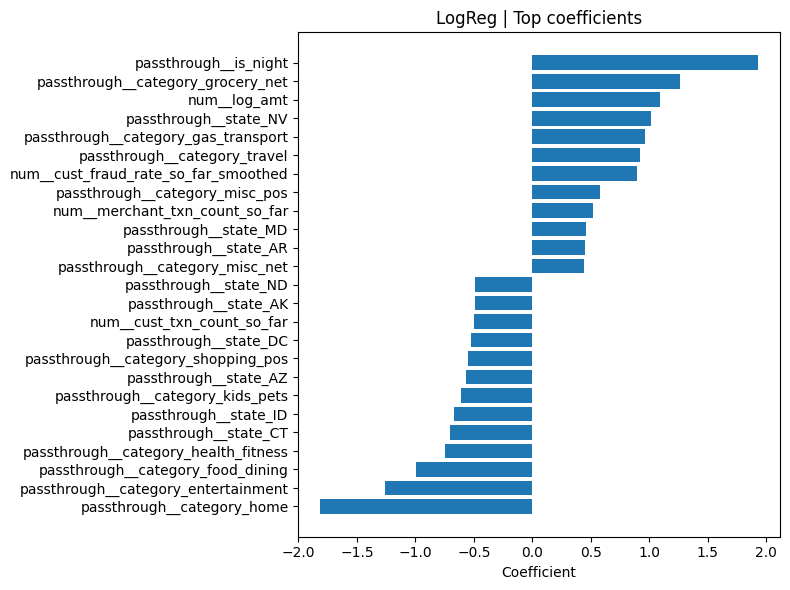

In [280]:
def plot_top_coefs(dfc, top_k=20, title="LogReg | Top coefficients"):
    d = dfc.sort_values("abs_coef", ascending=False).head(top_k).copy() #prende quelli con valori più alti pos e neg
    d = d.sort_values("coef")  # riordina nel modo corretto
    plt.figure(figsize=(8, 6))
    plt.barh(d["feature"], d["coef"])
    plt.title(title)
    plt.xlabel("Coefficient")
    plt.tight_layout()
    plt.show()

plot_top_coefs(dfc_all, top_k=25)


L’analisi dei coefficienti evidenzia segnali coerenti con l’intuizione di dominio.

Tra le feature che spingono verso la classificazione di frode emergono:

- is_night, a conferma della maggiore incidenza di frodi in fasce orarie notturne
- log_amt, che indica un aumento del rischio all’aumentare dell’importo
- cust_fraud_rate_so_far_smoothed, che cattura efficacemente il comportamento storico del cliente
- alcune categorie merceologiche tipicamente associate a frodi remote o digitali (es. grocery_net, travel, gas_transport)

Al contrario, alcune categorie di spesa quotidiana (home, food_dining, entertainment) e un’elevata numerosità di transazioni pregresse del cliente tendono a ridurre la probabilità stimata di frode, fungendo da segnali di normalità comportamentale.

È interessante notare come anche alcune feature geografiche (stato) assumano un peso significativo, probabilmente riflettendo pattern specifici del dataset piuttosto che relazioni causali generalizzabili.

**Interpretabilità – Random Forest**

La Random Forest fornisce una misura di importanza basata sulla riduzione media dell’impurità (MDI). Questa metrica è utile per una lettura “globale” dei driver del modello, ma può essere distorta in presenza di feature correlate o con molte possibili soglie di split (feature continue).

In [286]:
## Feature Importance Random Forest

def rf_feature_importance(model, feature_names, top_n=20):

    # Estrae e ordina le feature importance da un modello RF

    importances = model.feature_importances_

    fi_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False)

    return fi_df.head(top_n), fi_df

In [287]:
top20_rf, all_rf_importance = rf_feature_importance(
    model=rf_model,               # RF già addestrato
    feature_names=feature_names,  # già ordinati dal preprocessor
    top_n=20
)

top20_rf


,feature,importance
6,num__log_amt,0.6461
11,num__cust_fraud_count_so_far,0.1073
1,num__hour_cos,0.0979
13,num__cust_delta_prev_sec,0.0217
22,passthrough__hour,0.0163
31,passthrough__category_gas_transport,0.0101
14,num__merchant_risk_score_smoothed,0.0096
19,num__zip_txn_count_so_far,0.0085
42,passthrough__category_travel,0.0081
9,num__age,0.0081


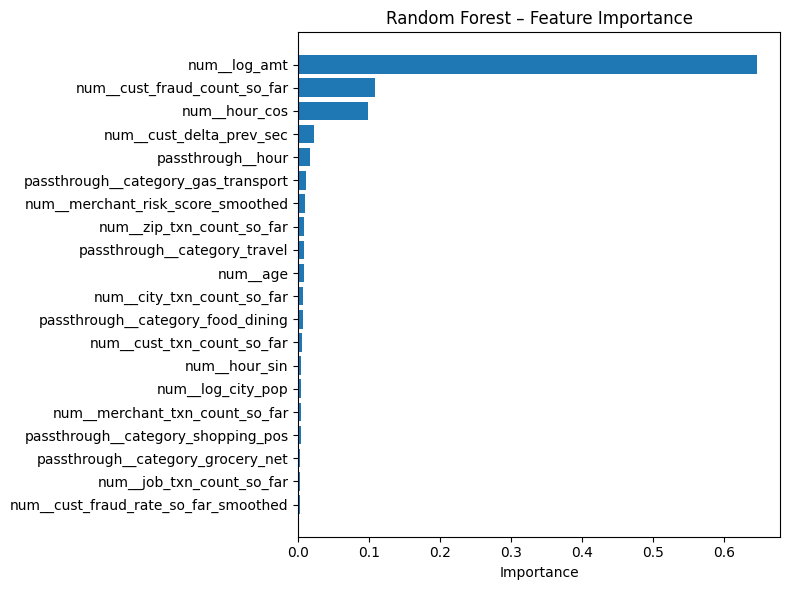

In [288]:
def plot_rf_feature_importance(fi_df, top_n=20):
    plt.figure(figsize=(8, 6))
    plt.barh(
        fi_df["feature"].iloc[::-1],
        fi_df["importance"].iloc[::-1]
    )
    plt.title("Random Forest – Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

plot_rf_feature_importance(top20_rf)


L’importanza è fortemente concentrata su log_amt, che domina la capacità di separazione del modello. Questo è plausibile in fraud detection (importi alti → rischio maggiore), ma segnala anche che la foresta sta costruendo molte regole basate su soglie dell’importo.

Subito dopo emergono feature comportamentali lato cliente (cust_fraud_count_so_far, cust_delta_prev_sec), e segnali temporali (hour_cos, hour), che confermano l’utilità del contesto e della recency.
Le feature di rischio smoothed (es. merchant_risk_score_smoothed) risultano presenti ma meno dominanti: è coerente con il fatto che una RF tende a catturare pattern forti con poche variabili (l’importo in questo caso) e a distribuire il resto su segnali secondari.

L’elevata importanza di log_amt potrebbe indicare anche una dipendenza eccessiva dall’importo; questo aspetto verrà verificato in analisi errori (FP su transazioni legittime ad importo elevato) e con SHAP.

**Interpretabilità con SHAP (XGBoost)**

Per il modello XGBoost, l’interpretabilità è stata analizzata tramite SHAP (SHapley Additive exPlanations), che consente di:
- quantificare l’impatto medio di ciascuna feature sulla predizione del modello (importanza globale);
- analizzare come il valore di una feature (alto/basso) influenzi la probabilità di frode;
- mantenere coerenza con il modello non lineare e con le interazioni apprese dagli alberi.

Una prima analisi è stata effettuata su un sotto-campione del dataset di test per motivi computazionali, preservando comunque la distribuzione originale dei dati.

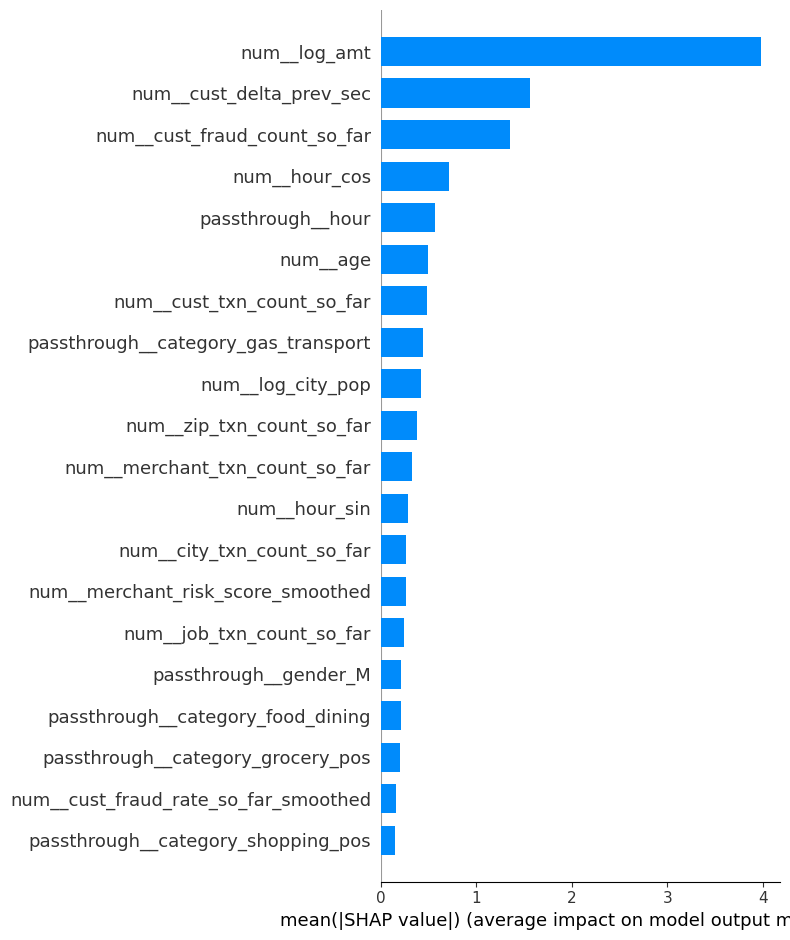

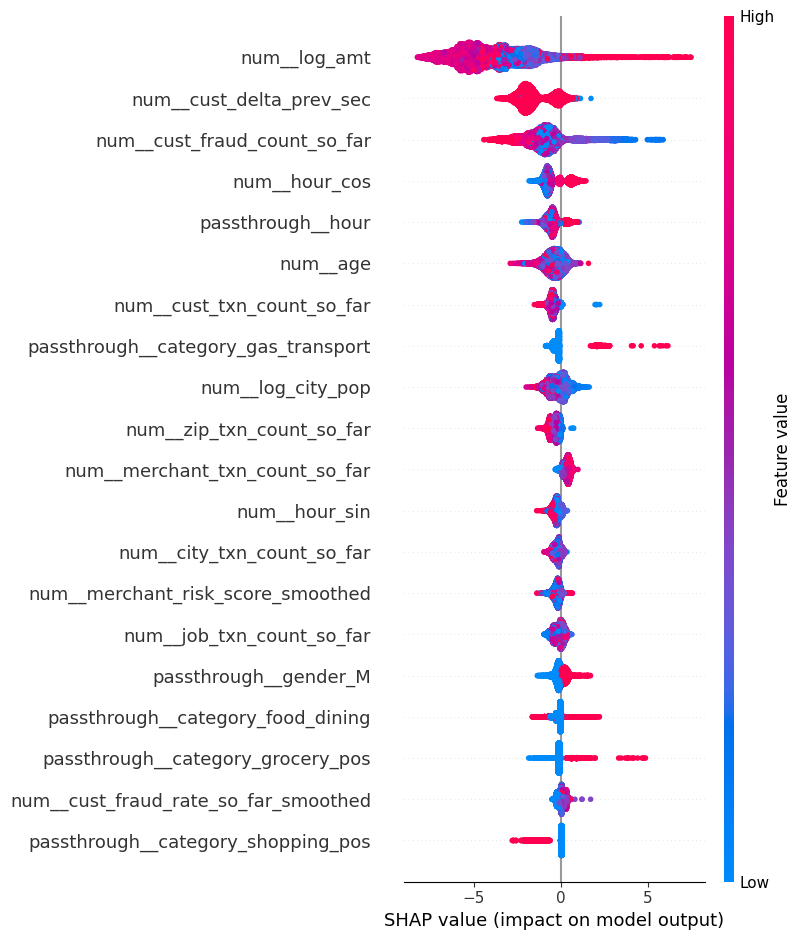

In [289]:
#SHAP su XGBoost

# 1) Campionamento (per velocizzare l'analisi)
# ----------------------------
def sample_matrix(X, n=50000, random_state=42):
    rng = np.random.RandomState(random_state)
    n_rows = X.shape[0]
    if n_rows <= n:
        idx = np.arange(n_rows)
    else:
        idx = rng.choice(n_rows, size=n, replace=False)
    return X[idx], idx

X_shap, shap_idx = sample_matrix(X_proc, n=20000, random_state=42)


# 2) Explainer + SHAP values

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)


# 3) Importanza globale (bar)

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar",
    show=True
)


# 4) Distribuzione effetti (beeswarm)

shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    show=True
)


**Importanza globale (bar plot)**

Il grafico di importanza SHAP conferma che il modello XGBoost è guidato principalmente da segnali di rischio forti e interpretabili:
- log_amt è di gran lunga la feature più influente: importi elevati aumentano significativamente il rischio di frode.
- Feature di comportamento temporale e recency (cust_delta_prev_sec, hour_cos, hour) hanno un peso rilevante, indicando che la dinamica temporale delle transazioni è cruciale.
- Storico cliente (cust_fraud_count_so_far, cust_txn_count_so_far) contribuisce in modo consistente, confermando il valore dell’informazione storica.
- Contesto geografico e demografico (log_city_pop, age) e contesto merchant (conteggi e risk score) giocano un ruolo secondario ma stabile.

Nel complesso, il modello combina segnali economici, temporali e storici, evitando di dipendere eccessivamente da singole feature categoriali.
###
**Distribuzione degli effetti (beeswarm plot)**

Il beeswarm consente di leggere direzione e non linearità degli effetti:
- log_amt mostra un effetto fortemente monotono: valori alti (rosso) spingono chiaramente verso la frode, mentre importi bassi riducono il rischio.
- cust_delta_prev_sec evidenzia che intervalli brevi tra transazioni aumentano la probabilità di frode, coerentemente con pattern di utilizzo anomalo.
- cust_fraud_count_so_far ha un effetto asimmetrico: pochi eventi pregressi possono già spostare significativamente la predizione.
- Le feature cicliche temporali (hour_cos, hour_sin) catturano pattern non lineari legati all’orario, senza introdurre discontinuità artificiali.
- Le feature categoriali (es. category_gas_transport, category_food_dining) hanno impatto più localizzato, contribuendo soprattutto in presenza di altri segnali forti.

Un aspetto rilevante è che non emergono feature “spurie” dominanti: l’impatto è distribuito e coerente con il dominio applicativo.

In [292]:
y[0]

np.int64(0)

In [297]:
print(f"{xgb_proba[0]:2f}")

0.000003


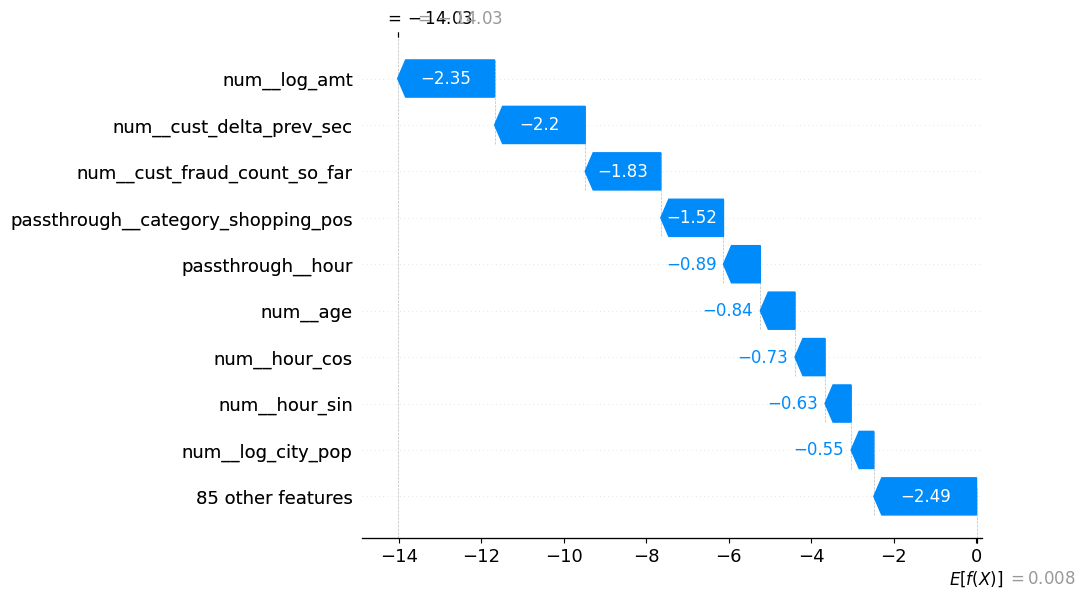

In [290]:
#SHAP su una riga a campione
i = 0  #proviamo con la prima

# base value (expected value) + shap values della riga
base_value = explainer.expected_value
sv = shap_values[i]
x_row = X_shap[i]

# Waterfall (spiegazione locale)
shap.plots._waterfall.waterfall_legacy(
    base_value,
    sv,
    feature_names=feature_names
)


Il waterfall plot mostra la scomposizione della predizione per una singola transazione, evidenziando come ciascuna feature contribuisca ad aumentare o diminuire la probabilità di frode rispetto al valore medio del modello.
- Il punto di partenza è il base value (expected value), che rappresenta la probabilità media di frode stimata dal modello sull’intero dataset.
- Ogni barra indica il contributo SHAP di una feature:
    - Valori negativi (verso sinistra) spingono la predizione verso legit.
    - Valori positivi (verso destra) spingono la predizione verso fraud.
      
Nel caso analizzato:
- log_amt (importo) contribuisce in modo marcato in negativo, indicando un importo coerente con transazioni legittime rispetto al pattern del modello.
- cust_delta_prev_sec e cust_fraud_count_so_far riducono ulteriormente il rischio stimato, suggerendo un comportamento temporale e uno storico cliente compatibili con normalità.
- Anche categoria e segnali temporali (hour, hour_sin/cos) spostano la previsione verso legit.

Label originale:  1


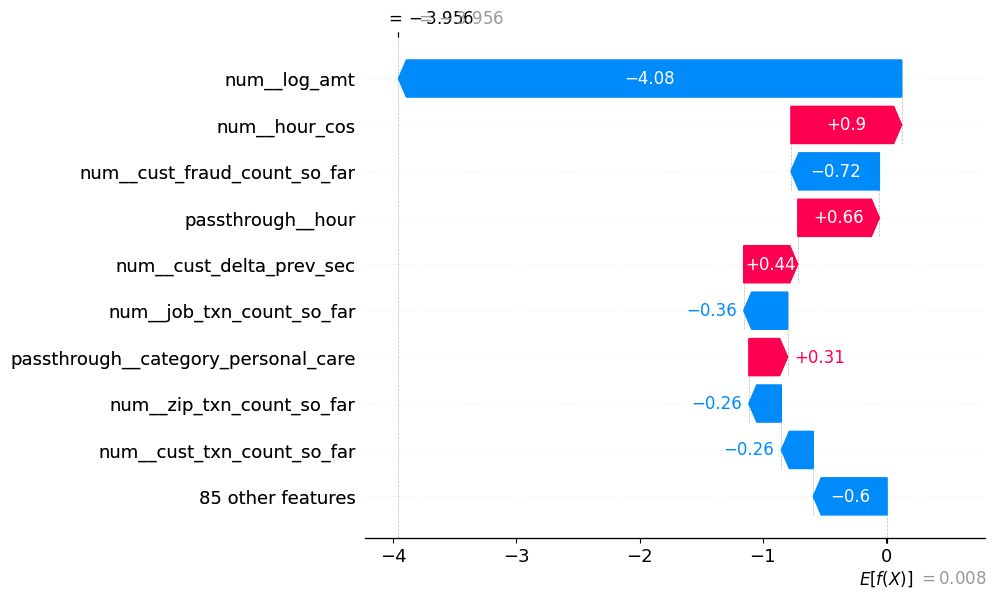

In [305]:
## esempio: primo FN

# richiede y_test e y_proba_test già calcolate
y_pred_test = (xgb_proba >= xgb_ths["Baseline"]).astype(int)

fn_idx = np.where((y.values == 1) & (y_pred_test == 0))[0][0]
print("Label originale: ", y[fn_idx])#check y originale

x_fn = X_proc[fn_idx:fn_idx+1]
sv_fn = explainer.shap_values(x_fn)[0]
shap.plots._waterfall.waterfall_legacy(base_value, sv_fn, feature_names=feature_names)


**Interpretazione business-oriented**

Questo FN è un caso tipico di fraud “low amount / trusted customer”:
- La frode avviene su importi bassi
- Coinvolge clienti senza storico negativo
- Il modello privilegia la riduzione dei falsi positivi e quindi sottostima questo tipo di rischio

È un comportamento coerente con l’ottimizzazione del costo: intercettare questo tipo di frodi richiederebbe soglie più aggressive, con un forte aumento dei FP.

In [309]:
## Analisi errori FP/FN

def error_summary(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall    = tp / (tp + fn) if (tp + fn) else 0.0

    out = {
        "threshold": float(threshold),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "precision_fraud": float(precision),
        "recall_fraud": float(recall),
    }
    return out, y_pred

def build_error_df(y_true, y_proba, y_pred, threshold):

    df_err = pd.DataFrame({
        "row_id": np.arange(len(y_true)),
        "y_true": y_true,
        "y_pred": y_pred,
        "proba_fraud": y_proba,
        "delta_to_th": (y_proba - threshold)
    })

    df_err["error_type"] = "OK"
    df_err.loc[(df_err.y_true == 0) & (df_err.y_pred == 1), "error_type"] = "FP"
    df_err.loc[(df_err.y_true == 1) & (df_err.y_pred == 0), "error_type"] = "FN"

    return df_err

def analyze_fp_fn(
    y_true,
    y_proba,
    threshold,
    X_test,           # df con colonne originali/feature (per ispezione)
    top_k=10,
    show_report=True
):
    summ, y_pred = error_summary(y_true, y_proba, threshold)
    df_err = build_error_df(y_true, y_proba, y_pred, threshold)
    df_err = pd.concat([df_err, X_test], axis=1)


    if show_report:
        print("=== Summary ===")
        print(summ)
        print("\n=== Classification report (threshold={:.4f}) ===".format(threshold))
        print(classification_report(y_true, y_pred, target_names=["legit","fraud"], digits=4))

    # FN: y_true=1, y_pred=0 -> ordina per proba desc (quelli più “quasi presi”)
    fn_df = df_err[df_err["error_type"] == "FN"].sort_values("proba_fraud", ascending=False).head(top_k)

    # FP: y_true=0, y_pred=1 -> ordina per proba desc (più convinti fossero frodi)
    fp_df = df_err[df_err["error_type"] == "FP"].sort_values("proba_fraud", ascending=False).head(top_k)

    print("\n--- Top FN (frodi mancate con proba più alta) ---")
    display(fn_df)

    print("\n--- Top FP (legittime bloccate con proba più alta) ---")
    display(fp_df)

    return summ, df_err, fn_df, fp_df


In [310]:
lr_ths['Baseline']#check

np.float64(0.8422613065326634)

In [312]:
LEVEL = "Baseline"  # oppure "Conservative", "Medium-high", "High"
top_k = 10

X_test = df_test.copy()
X_test = X_test.sort_values("trans_date_trans_time").reset_index(drop=True)

# LOG REG
print("\n================ LOGISTIC REGRESSION ================\n")
summ_lr, err_lr, fn_lr, fp_lr = analyze_fp_fn(
    y_true = y,
    y_proba = log_reg_proba,
    threshold = lr_ths[LEVEL],
    X_test = X_test,
    top_k=top_k
)

# RANDOM FOREST
print("\n================ RANDOM FOREST ================\n")
summ_rf, err_rf, fn_rf, fp_rf = analyze_fp_fn(
    y_true = y,
    y_proba = rf_proba,
    threshold = rf_ths[LEVEL],
    X_test = X_test,
    top_k=top_k
)

# XGBOOST
print("\n================ XGBOOST ================\n")
summ_xgb, err_xgb, fn_xgb, fp_xgb = analyze_fp_fn(
    y_true = y,
    y_proba = xgb_proba,
    threshold = xgb_ths[LEVEL],
    X_test = X_test,
    top_k=top_k
)



================ LOGISTIC REGRESSION ================

=== Summary ===
{'threshold': 0.8422613065326634, 'tn': 553378, 'fp': 196, 'fn': 1898, 'tp': 247, 'precision_fraud': 0.5575620767494357, 'recall_fraud': 0.11515151515151516}

=== Classification report (threshold=0.8423) ===
              precision    recall  f1-score   support

       legit     0.9966    0.9996    0.9981    553574
       fraud     0.5576    0.1152    0.1909      2145

    accuracy                         0.9962    555719
   macro avg     0.7771    0.5574    0.5945    555719
weighted avg     0.9949    0.9962    0.9950    555719


--- Top FN (frodi mancate con proba più alta) ---


,row_id,y_true,y_pred,proba_fraud,delta_to_th,error_type,Unnamed: 0,trans_date_trans_time,cc_num,merchant,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
488684,488684,1,0,0.8418,-0.0004,FN,488684,2020-12-16 22:42:18,2714019737356678,"fraud_Ruecker, Beer and Collier",...,39.9914,-80.4408,724,Theme park manager,1995-08-30,9848478758f1a3d08e475cc30787a5bf,1387233738,40.8900,-80.0892,1
58744,58744,1,0,0.8401,-0.0022,FN,58744,2020-07-11 23:42:56,675961917837,"fraud_Heathcote, Yost and Kertzmann",...,40.6267,-96.7456,142,Chiropodist,1967-08-24,ff4355de842f8bd05de6f23e14fc3bf0,1373586176,40.7490,-96.9829,1
118000,118000,1,0,0.8392,-0.0031,FN,118000,2020-08-01 22:21:51,3576281490078437,fraud_Heathcote LLC,...,38.7735,-86.6285,1735,Financial adviser,1990-06-13,f5cf83ea7b63338db4a940342e7243c9,1375395711,38.7908,-87.1607,1
206067,206067,1,0,0.8383,-0.0040,FN,206067,2020-09-01 10:45:58,180052752563109,"fraud_Moen, Reinger and Murphy",...,38.8590,-77.0997,207410,Historic buildings inspector/conservation officer,1968-11-14,eb81aa60bf1c8b8621a8fb7fc9253afb,1378032358,38.1777,-78.0494,1
133300,133300,1,0,0.8379,-0.0044,FN,133300,2020-08-06 22:15:19,348253506557335,"fraud_Streich, Dietrich and Barton",...,30.4983,-88.3282,15647,Armed forces logistics/support/administrative ...,1948-03-22,f652df33e5877d73c422fa8799db45b3,1375827319,30.3959,-89.1911,1
282396,282396,1,0,0.8374,-0.0048,FN,282396,2020-10-04 23:29:53,30510856607165,"fraud_Little, Gutmann and Lynch",...,42.3958,-83.3772,96942,Horticultural consultant,1965-04-01,ed49b06e46ac4cddb11cfa1de3f865f5,1380929393,43.0991,-82.9952,1
98257,98257,1,0,0.8370,-0.0053,FN,98257,2020-07-25 21:43:42,38014427445058,fraud_Jast Ltd,...,43.8967,-89.8219,3508,Sport and exercise psychologist,1946-08-11,59150de6c122d18f500f13f31cff1078,1374788622,43.0317,-89.1493,1
22015,22015,1,0,0.8370,-0.0053,FN,22015,2020-06-28 23:48:51,3581130339108561,"fraud_Heathcote, Yost and Kertzmann",...,41.0695,-81.5488,272134,Call centre manager,1964-03-15,041e573c99f5f86a5110a99a2227d976,1372463331,40.1996,-81.1086,1
58772,58772,1,0,0.8362,-0.0061,FN,58772,2020-07-11 23:57:24,675961917837,fraud_Heathcote LLC,...,40.6267,-96.7456,142,Chiropodist,1967-08-24,d9d450cf71badbc4167d0f5240009cb1,1373587044,41.3479,-96.0427,1
346223,346223,1,0,0.8346,-0.0076,FN,346223,2020-11-01 23:45:08,4087542780207162,fraud_Rau-Robel,...,35.8330,-97.4360,20226,Retail manager,1969-11-08,3ea4b398c6063d238001af3849f06a20,1383349508,36.3167,-97.0188,1



--- Top FP (legittime bloccate con proba più alta) ---


,row_id,y_true,y_pred,proba_fraud,delta_to_th,error_type,Unnamed: 0,trans_date_trans_time,cc_num,merchant,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
517033,517033,0,1,0.9837,0.1415,FP,517033,2020-12-22 21:30:34,4725837176265195730,fraud_Corwin-Romaguera,...,30.8985,-87.1332,5719,Higher education careers adviser,1994-11-05,932aef04df2c7a1f4d53127eb1bd71f2,1387747834,30.7431,-86.2942,0
5934,5934,0,1,0.9754,0.1332,FP,5934,2020-06-22 23:06:08,2610529083834453,fraud_Cormier LLC,...,36.2416,-86.6117,22191,Prison officer,1994-07-27,f9c914fa8ddc2a131b88dcaef8b08f83,1371942368,35.5451,-85.6498,0
157707,157707,0,1,0.9720,0.1297,FP,157707,2020-08-15 22:19:00,30541100351706,fraud_Schumm PLC,...,30.0377,-95.5326,316665,"Education officer, museum",1990-09-12,f8ffaad81eabe062fe1dd80b234e8240,1376605140,30.4267,-94.7219,0
400011,400011,0,1,0.9674,0.1252,FP,400011,2020-11-24 22:54:15,6535328428560433,fraud_Kovacek Ltd,...,45.0632,-93.3811,1022298,Analytical chemist,1967-10-28,b7a9fa52534a9afcaf4d17d729339654,1385333655,44.1954,-93.6668,0
11665,11665,0,1,0.9667,0.1244,FP,11665,2020-06-24 22:02:46,3528407217576457,fraud_Schumm PLC,...,36.4715,-82.4834,87124,Warden/ranger,1987-02-14,7f21398fbd5ac5c25a3653b905b103b1,1372111366,35.5967,-82.5056,0
2330,2330,0,1,0.9645,0.1222,FP,2330,2020-06-22 02:28:52,3598634130286287,fraud_Kilback LLC,...,41.2064,-95.9953,518429,"Surveyor, land/geomatics",1995-10-10,e1d878e86624225cde4d0129e8083b7b,1371868132,40.7114,-96.0984,0
32033,32033,0,1,0.9591,0.1168,FP,32033,2020-07-02 01:33:46,4605902936394,fraud_Schumm PLC,...,32.8770,-96.7080,1263321,Drilling engineer,1959-06-28,abc49ab10396d16b6f89df633b4177d1,1372728826,32.4600,-95.9664,0
75917,75917,0,1,0.9590,0.1168,FP,75917,2020-07-17 21:06:04,4710826438164847414,fraud_Gislason Group,...,48.8328,-108.3961,192,Further education lecturer,1964-01-04,1cc16e75c5d00f1ead3fa5b3492d60c9,1374095164,48.7011,-107.7702,0
488456,488456,0,1,0.9577,0.1154,FP,488456,2020-12-16 21:16:07,4378993458389626,fraud_Boyer-Haley,...,43.9742,-71.1503,3807,Surgeon,1999-10-25,787b3a6dae2fad86d24e89ec9e13482b,1387228567,43.0725,-71.1178,0
6593,6593,0,1,0.9564,0.1141,FP,6593,2020-06-23 04:03:02,30491348102802,fraud_Kilback LLC,...,39.6094,-100.4112,169,"Librarian, public",1953-07-30,493ff77d9fd6fded0256d5975f094dce,1371960182,40.3426,-100.6630,0



================ RANDOM FOREST ================

=== Summary ===
{'threshold': 0.46798994974874375, 'tn': 551986, 'fp': 1588, 'fn': 560, 'tp': 1585, 'precision_fraud': 0.4995272612669398, 'recall_fraud': 0.7389277389277389}

=== Classification report (threshold=0.4680) ===
              precision    recall  f1-score   support

       legit     0.9990    0.9971    0.9981    553574
       fraud     0.4995    0.7389    0.5961      2145

    accuracy                         0.9961    555719
   macro avg     0.7493    0.8680    0.7971    555719
weighted avg     0.9971    0.9961    0.9965    555719


--- Top FN (frodi mancate con proba più alta) ---


...

,row_id,y_true,y_pred,proba_fraud,delta_to_th,error_type,Unnamed: 0,trans_date_trans_time,cc_num,merchant,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
135993,135993,0,1,1.0000,0.5320,FP,135993,2020-08-08 02:13:13,376445266762684,fraud_Kutch and Sons,...,41.1558,-101.1360,1789,Insurance broker,1982-02-11,398c9d221d4fb18eaff5af1007044de0,1375927993,41.5717,-101.8685,1
200745,200745,0,1,0.9981,0.5301,FP,200745,2020-08-31 01:14:14,6596735789587928,fraud_Deckow-O'Conner,...,44.9595,-93.8482,5619,Licensed conveyancer,1959-01-15,14e3b6f5bda12ff26a8490b5570d5b6d,1377911654,44.7928,-93.4750,1
263802,263802,0,1,0.9947,0.5267,FP,263802,2020-09-27 01:16:23,4904681492230012,fraud_Huel Ltd,...,41.8467,-74.1038,722,Comptroller,1990-10-19,57a31188c8462698ca144f6a5d4439d2,1380244583,40.9116,-74.5529,0
349486,349486,0,1,0.9930,0.5250,FP,349486,2020-11-03 00:55:10,4178097073221156,fraud_Koelpin and Sons,...,41.9488,-86.4913,3104,"Horticulturist, commercial",1981-03-29,fbed06b4db865cd4ec03d7dae8c29aab,1383440110,42.4598,-86.9181,0
409806,409806,0,1,0.9912,0.5233,FP,409806,2020-11-30 00:43:06,3577578023716568,fraud_Dach-Nader,...,41.0935,-81.0425,2644,"Engineer, biomedical",1983-08-25,6732646e08a5c3ba4228ea2beeacc202,1385772186,41.8907,-81.6180,0
106223,106223,0,1,0.9888,0.5208,FP,106223,2020-07-28 02:38:40,6011893664860915,fraud_Welch Inc,...,39.5994,-105.0044,320420,Water engineer,1975-07-31,5f5a35bc30a5a768e31fce4c9b710291,1374979120,40.4519,-105.9115,0
378470,378470,0,1,0.9884,0.5205,FP,378470,2020-11-16 02:18:17,3563837241599446,fraud_Jaskolski-Vandervort,...,45.3099,-122.9685,28278,Research scientist (physical sciences),1977-07-17,7a1c70accb449d8c53b7d2560e28eabb,1384568297,45.9290,-123.1477,0
54063,54063,0,1,0.9770,0.5090,FP,54063,2020-07-10 00:12:37,3563837241599446,fraud_McGlynn-Heathcote,...,45.3099,-122.9685,28278,Research scientist (physical sciences),1977-07-17,fab61ead9131e7d988ac0b40752ee7ea,1373415157,46.1835,-123.9429,0
224275,224275,0,1,0.9761,0.5081,FP,224275,2020-09-08 22:14:07,4335531783520911,"fraud_Reichert, Rowe and Mraz",...,38.3511,-91.4867,6703,Naval architect,1998-05-20,00d133dfea29e9b2bc721f1096357a58,1378678447,39.2949,-91.4155,0
357405,357405,0,1,0.9750,0.5070,FP,357405,2020-11-06 22:52:25,4170689372027579,fraud_Gerlach Inc,...,35.6665,-97.4798,116001,Media buyer,1993-05-10,48ece60a4af5626647ace6c16be1db66,1383778345,35.9569,-98.4062,0



================ XGBOOST ================

=== Summary ===
{'threshold': 0.23160804020100503, 'tn': 552669, 'fp': 905, 'fn': 382, 'tp': 1763, 'precision_fraud': 0.6607946026986506, 'recall_fraud': 0.8219114219114219}

=== Classification report (threshold=0.2316) ===
              precision    recall  f1-score   support

       legit     0.9993    0.9984    0.9988    553574
       fraud     0.6608    0.8219    0.7326      2145

    accuracy                         0.9977    555719
   macro avg     0.8301    0.9101    0.8657    555719
weighted avg     0.9980    0.9977    0.9978    555719


--- Top FN (frodi mancate con proba più alta) ---


,row_id,y_true,y_pred,proba_fraud,delta_to_th,error_type,Unnamed: 0,trans_date_trans_time,cc_num,merchant,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
387443,387443,1,0,0.2310,-0.0006,FN,387443,2020-11-19 21:29:11,6538441737335434,"fraud_Greenfelder, Bartoletti and Davis",...,41.3851,-80.1752,606,Energy manager,1997-09-22,ee5900b043f40d0188f371fc5f0b6908,1384896551,41.4092,-81.0725,1
121382,121382,1,0,0.2295,-0.0022,FN,121382,2020-08-02 22:30:14,3577794103155425,"fraud_Streich, Rolfson and Wilderman",...,47.7068,-97.2092,733,Visual merchandiser,1994-11-12,534e600a6714a208c566540c950513eb,1375482614,46.7341,-98.1510,1
211725,211725,1,0,0.2278,-0.0039,FN,211725,2020-09-03 23:27:10,4509142395811241,fraud_Ernser-Feest,...,31.6489,-82.1982,1324,"Engineer, technical sales",1926-07-12,0c2557a59fe3ea4f8b615360f8ed89ed,1378250830,31.5256,-82.6540,1
304225,304225,1,0,0.2275,-0.0041,FN,304225,2020-10-13 21:15:33,4129767952109660,"fraud_Schiller, Blanda and Johnson",...,47.3551,-96.7980,771,"Scientist, audiological",1972-06-14,593cb928bcefeb165233d0855f6b3972,1381698933,47.3589,-97.0689,1
402308,402308,1,0,0.2200,-0.0116,FN,402308,2020-11-26 11:40:33,5410056176712193,fraud_McGlynn-Heathcote,...,44.5592,-87.8235,4306,Art therapist,1989-10-19,a98eb7b63ba4fb03b123d1d6f05a7ef9,1385466033,44.0453,-86.9764,1
36476,36476,1,0,0.2130,-0.0186,FN,36476,2020-07-04 03:30:13,4989847570577635369,fraud_Macejkovic-Lesch,...,34.1832,-81.5324,8333,Archaeologist,1994-07-09,d4e1ced955e544fe79c731b09eb53b4c,1372908613,33.4642,-81.3176,1
285608,285608,1,0,0.2052,-0.0265,FN,285608,2020-10-05 23:40:18,30011465039817,"fraud_Ledner, Hartmann and Feest",...,42.3496,-73.5873,4015,Human resources officer,1971-10-14,9c78d6f0b786bff44d1ad6fd5fa69fd4,1381016418,43.1879,-73.9523,1
295500,295500,1,0,0.2043,-0.0273,FN,295500,2020-10-10 22:07:21,4104312520615374,"fraud_Swaniawski, Lowe and Robel",...,33.6401,-116.5567,1661,"Therapist, music",1988-09-19,972a1a17dc018da6db1d52134a192ac9,1381442841,32.6610,-115.6114,1
467739,467739,1,0,0.2017,-0.0299,FN,467739,2020-12-12 22:19:18,4607072969078276,fraud_Skiles LLC,...,35.8985,-97.2607,1493,Amenity horticulturist,1985-03-21,d65b2a2334591a29b5110306ba39712c,1386886758,36.5681,-97.9759,1
238491,238491,1,0,0.1985,-0.0331,FN,238491,2020-09-15 06:51:03,4229733778084049,"fraud_Kerluke, Kertzmann and Wiza",...,37.6848,-85.8784,48194,Surgeon,1990-05-03,26de4cb73bfc118e0b219c8b5c26b4b2,1379227863,37.5869,-86.0728,1



--- Top FP (legittime bloccate con proba più alta) ---


,row_id,y_true,y_pred,proba_fraud,delta_to_th,error_type,Unnamed: 0,trans_date_trans_time,cc_num,merchant,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
245761,245761,0,1,0.9992,0.7676,FP,245761,2020-09-18 22:22:42,4005676619255478,fraud_Jacobi and Sons,...,30.4590,-90.9027,71335,Herbalist,1994-05-31,03b6eb59edd84fe3f0b0ab92a29f8a54,1379542962,31.3087,-90.3894,0
200745,200745,0,1,0.9991,0.7674,FP,200745,2020-08-31 01:14:14,6596735789587928,fraud_Deckow-O'Conner,...,44.9595,-93.8482,5619,Licensed conveyancer,1959-01-15,14e3b6f5bda12ff26a8490b5570d5b6d,1377911654,44.7928,-93.4750,1
135993,135993,0,1,0.9990,0.7674,FP,135993,2020-08-08 02:13:13,376445266762684,fraud_Kutch and Sons,...,41.1558,-101.1360,1789,Insurance broker,1982-02-11,398c9d221d4fb18eaff5af1007044de0,1375927993,41.5717,-101.8685,1
109452,109452,0,1,0.9982,0.7666,FP,109452,2020-07-28 22:26:11,30290551782700,fraud_Volkman Ltd,...,36.8020,-87.8286,13422,Commissioning editor,1961-09-03,7325dda2a2fce7d79b9365f9f4ed8603,1375050371,36.6151,-88.7592,1
425321,425321,0,1,0.9973,0.7657,FP,425321,2020-12-02 23:44:17,4005676619255478,"fraud_Swaniawski, Nitzsche and Welch",...,30.4590,-90.9027,71335,Herbalist,1994-05-31,4e146a6f059190d8e53660a93d4b65e2,1386027857,30.9422,-90.9334,0
81775,81775,0,1,0.9955,0.7639,FP,81775,2020-07-19 22:38:32,375534208663984,"fraud_Reichert, Shanahan and Hayes",...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,8a449d7fd31a1bed7ea3d727aa4df4a6,1374273512,38.4425,-78.5563,1
133301,133301,0,1,0.9945,0.7629,FP,133301,2020-08-06 22:15:47,4005676619255478,fraud_Williamson LLC,...,30.4590,-90.9027,71335,Herbalist,1994-05-31,6d581e11437e4887d9dccfa7c86f7c8b,1375827347,31.2149,-91.5085,0
256566,256566,0,1,0.9938,0.7622,FP,256566,2020-09-22 22:49:37,4005676619255478,"fraud_Boehm, Block and Jakubowski",...,30.4590,-90.9027,71335,Herbalist,1994-05-31,190bfb934c20f721288cd09b7fbe0f8b,1379890177,31.1812,-91.2197,0
349207,349207,0,1,0.9929,0.7613,FP,349207,2020-11-02 22:53:53,3545109339866548,"fraud_Zboncak, Rowe and Murazik",...,33.4783,-90.5142,2870,Chartered public finance accountant,1999-03-05,889c80ff7691609c6612e75053832423,1383432833,33.2379,-91.1486,0
505161,505161,0,1,0.9925,0.7609,FP,505161,2020-12-20 23:32:31,4005676619255478,fraud_Abbott-Steuber,...,30.4590,-90.9027,71335,Herbalist,1994-05-31,1d4a653b06159fa13982cc80eb0a2dae,1387582351,29.6501,-90.6250,0


L’analisi degli errori evidenzia differenze nette tra i modelli:

- Logistic Regression: con la soglia “Baseline” produce pochissimi FP (196) ma molti FN (1898). In pratica è molto conservativa nel segnalare frodi: quando segnala, spesso ha ragione (precision alta), ma perde gran parte delle frodi (recall basso). I “Top FN” sono casi al limite della soglia (delta_to_th vicino a 0), segnale che l’errore è spesso dovuto a probabilità appena sotto cutoff.
- Random Forest: migliora notevolmente la copertura delle frodi (recall ~0.74) al prezzo di più FP (1588). I FN principali sono anch’essi vicini alla soglia (proba appena sotto 0.468), quindi l’errore è spesso “borderline”; qui la soglia influenza molto il trade-off.
- XGBoost: è il miglior compromesso: FP contenuti (905) e FN ridotti (382) con precision e recall entrambe alte. Nei Top FN le probabilità sono appena sotto soglia (~0.23), mentre nei Top FP il modello assegna probabilità molto alte (≈0.99): questi FP sono “hard negatives” e candidati ideali per capire pattern di confusione (es. merchant ricorrenti, categorie/contesti specifici), perché il modello è molto convinto.

In [314]:
## Sovrapposizione degli errori tra modelli

def error_set(df_err, err_type):
    return set(df_err.loc[df_err["error_type"] == err_type, "row_id"])

fn_sets = {
    "LR":  error_set(err_lr, "FN"),
    "RF":  error_set(err_rf, "FN"),
    "XGB": error_set(err_xgb, "FN"),
}
fp_sets = {
    "LR":  error_set(err_lr, "FP"),
    "RF":  error_set(err_rf, "FP"),
    "XGB": error_set(err_xgb, "FP"),
}

print("FN overlap (LR&RF):", len(fn_sets["LR"] & fn_sets["RF"])) #quanti elementi in comune nei due set di confronto
print("FN overlap (LR&XGB):", len(fn_sets["LR"] & fn_sets["XGB"]))
print("FN overlap (RF&XGB):", len(fn_sets["RF"] & fn_sets["XGB"]))

print("FP overlap (LR&RF):", len(fp_sets["LR"] & fp_sets["RF"]))
print("FP overlap (LR&XGB):", len(fp_sets["LR"] & fp_sets["XGB"]))
print("FP overlap (RF&XGB):", len(fp_sets["RF"] & fp_sets["XGB"]))


FN overlap (LR&RF): 547
FN overlap (LR&XGB): 382
FN overlap (RF&XGB): 362
FP overlap (LR&RF): 10
FP overlap (LR&XGB): 19
FP overlap (RF&XGB): 385


Confrontando gli insiemi di errori:

- FN (frodi mancate): c’è una sovrapposizione significativa tra modelli. In particolare LR&RF condividono 547 FN, mentre LR&XGB 382 e RF&XGB 362. Questo suggerisce che una parte delle frodi è intrinsecamente difficile (pattern poco informativi o simili a transazioni lecite) e tende a “sfuggire” a più modelli.

- FP (falsi allarmi): qui la sovrapposizione è molto diversa. LR condivide pochissimi FP con gli altri (10 con RF, 19 con XGB), segno che la LR “sbaglia” su casi diversi (ed è molto più conservativa nel segnalare). Invece RF&XGB condividono 385 FP, indicando che i due modelli non-lineari identificano pattern simili come sospetti: questi sono ottimi candidati per analisi qualitativa (merchant/categorie ricorrenti).

Selected FN ids: [387443, 121382, 211725]
Selected FP ids: [245761, 200745, 135993]


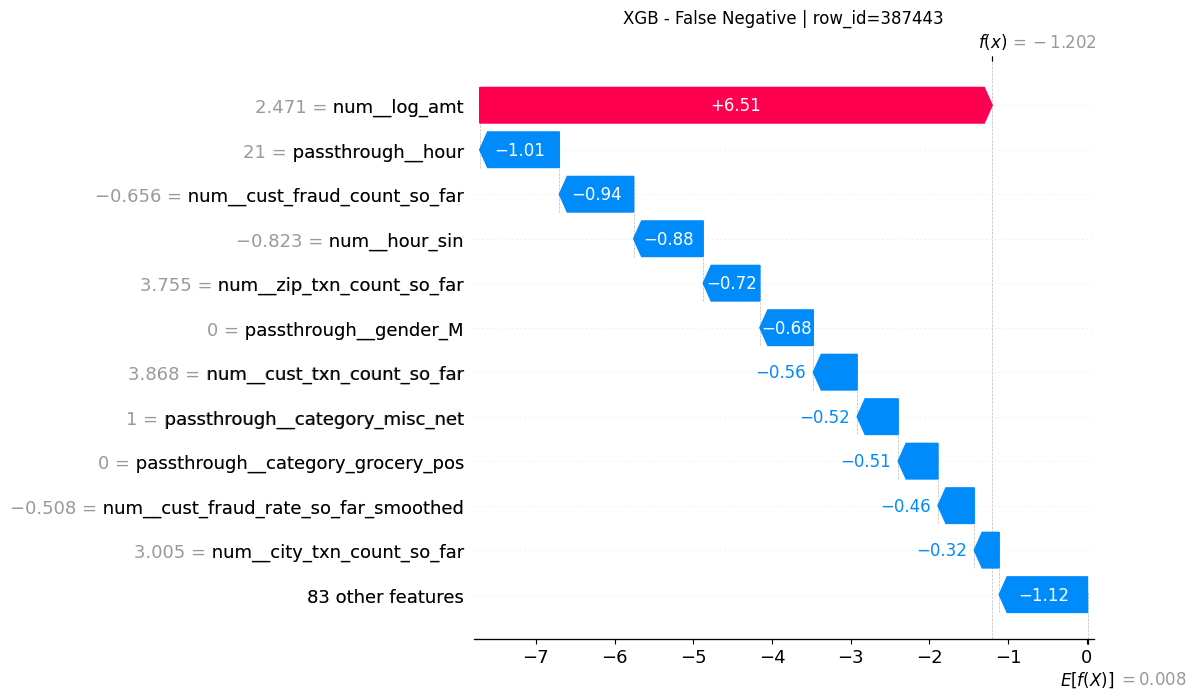

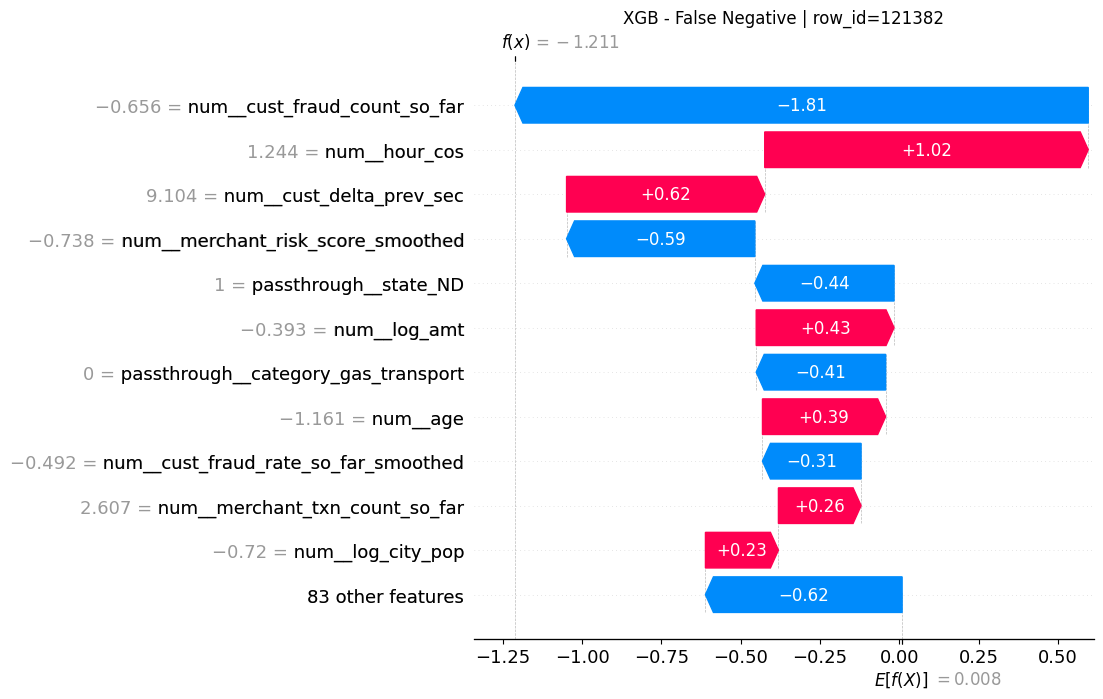

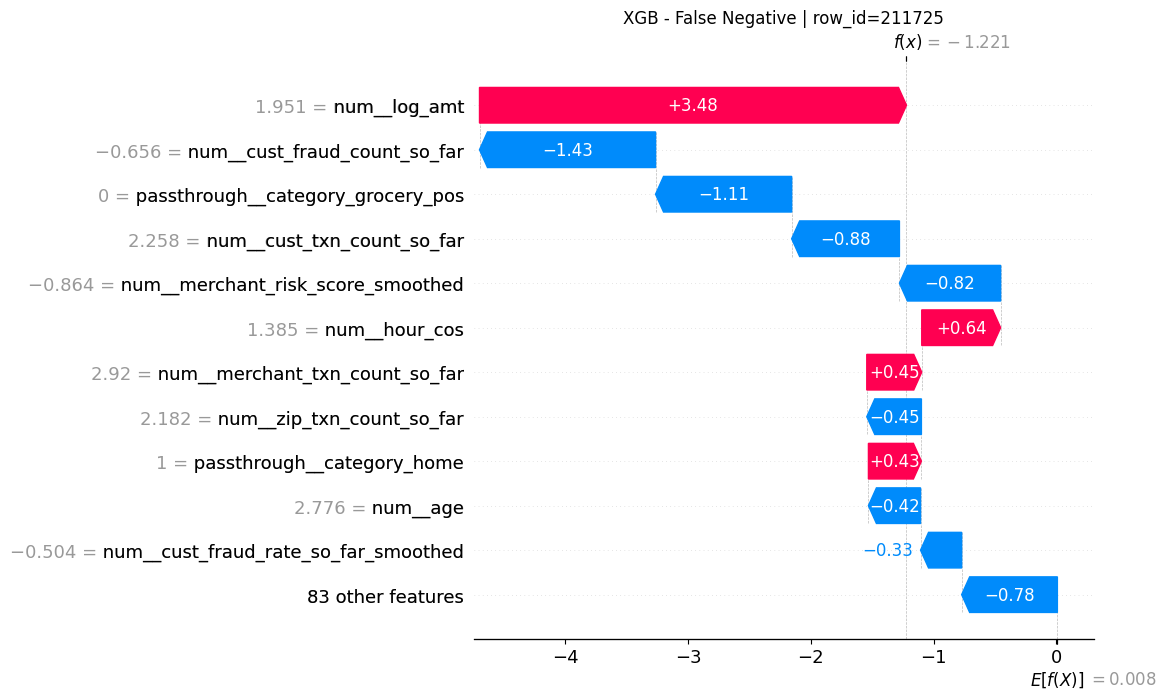

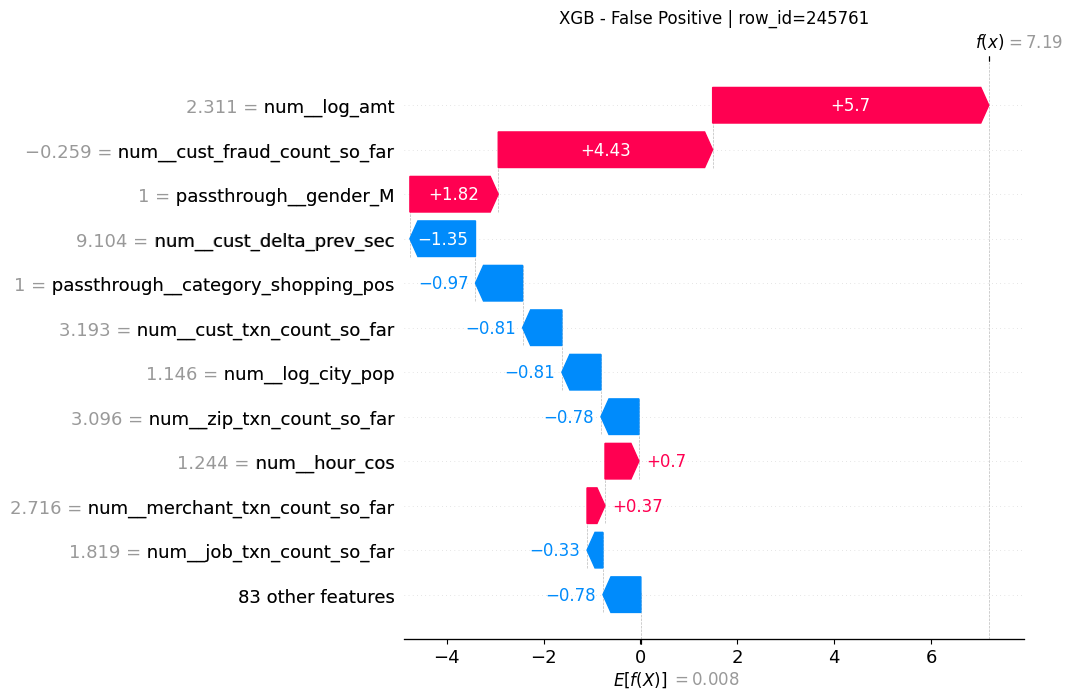

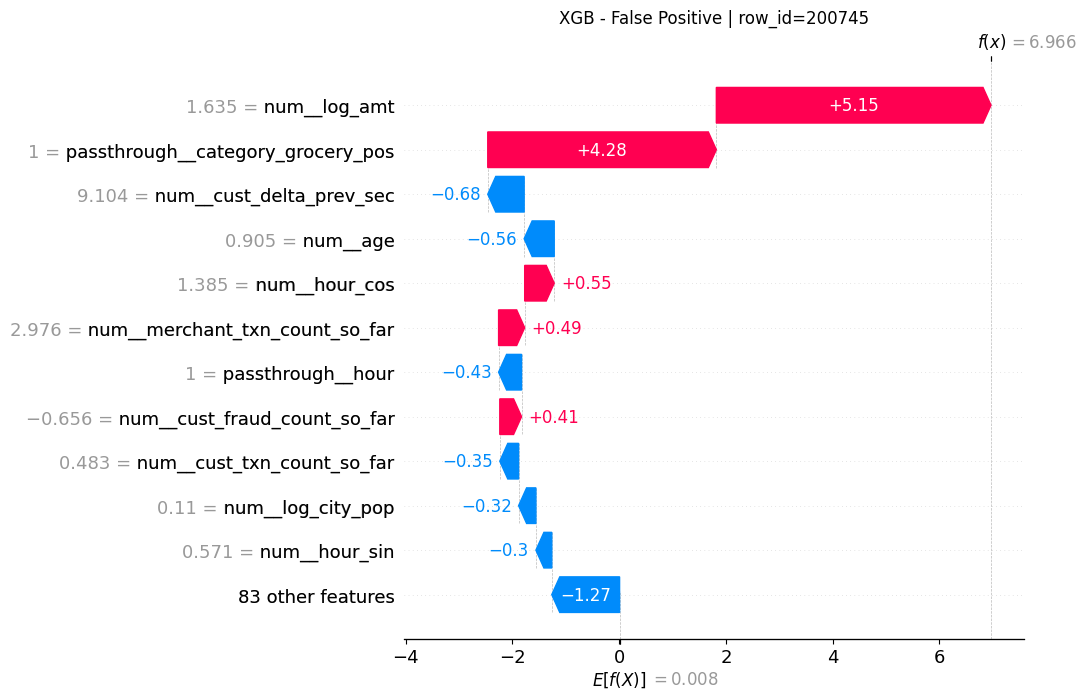

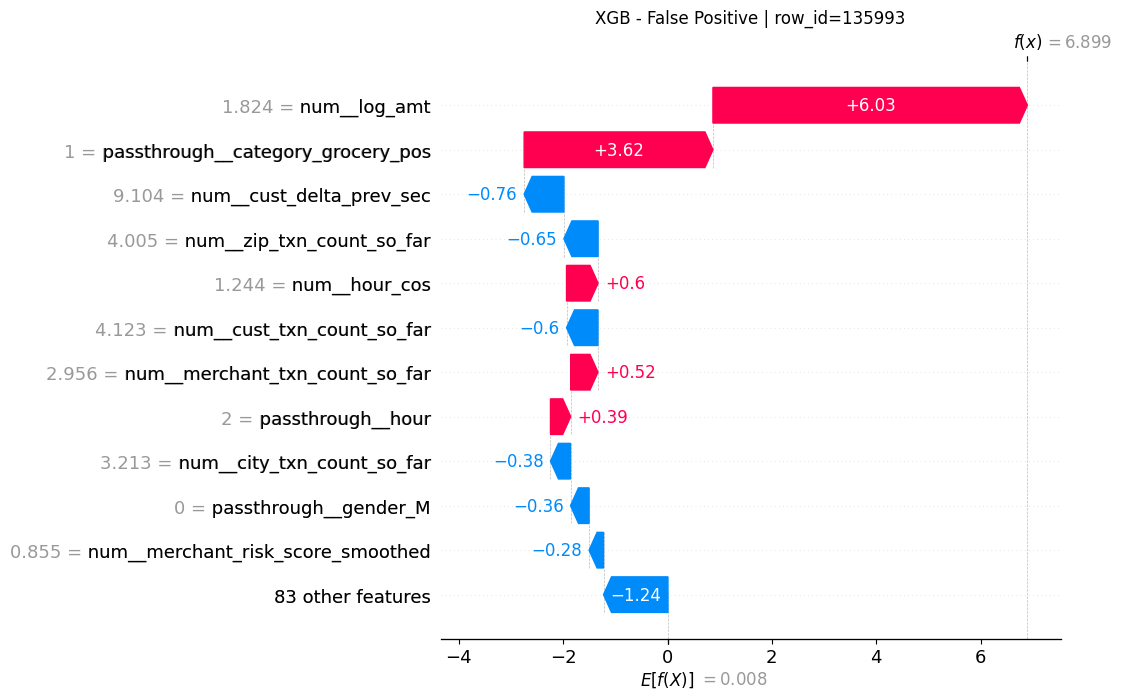

In [317]:
#analisi SHAP top 3 FN e FP

top_k = 3 #modificabile

fn_xg_topk =  fn_xgb.head(top_k)
fp_xgb_topk = fp_xgb.head(top_k)

# --- scegli 2-3 FN e 2-3 FP ---
fn_ids = fn_xg_topk["row_id"].astype(int).tolist()
fp_ids = fp_xgb_topk["row_id"].astype(int).tolist()

print("Selected FN ids:", fn_ids)
print("Selected FP ids:", fp_ids)

# --- calcolo shap values SOLO per le righe scelte (più veloce) ---
selected_ids = fn_ids + fp_ids

# attenzione: se X_test_proc è numpy array va bene così
X_sel = X_proc[selected_ids]

#DataFrame con nomi feature -> SHAP usa i nomi corretti
X_sel_df = pd.DataFrame(X_sel, columns=feature_names)

shap_values_sel = explainer(X_sel_df)  # ritorna shap.Explanation con feature name

# --- waterfall plot: uno per riga ---
def plot_waterfalls(shap_values, ids, title_prefix):
    for j, rid in enumerate(ids):
        shap.plots.waterfall(shap_values[j], max_display=12, show=False)
        plt.title(f"{title_prefix} | row_id={rid}")
        plt.show()

# I primi len(fn_ids) sono FN, i restanti FP
plot_waterfalls(shap_values_sel[:len(fn_ids)], fn_ids, "XGB - False Negative")
plot_waterfalls(shap_values_sel[len(fn_ids):], fp_ids, "XGB - False Positive")


**Analisi SHAP su top FN e FP (XGBoost)**

L’analisi SHAP dei False Negative mostra che le frodi mancate sono spesso caratterizzate da segnali contrastanti: importi elevati (num__log_amt) o pattern temporali sospetti spingono verso la classe fraud, ma vengono controbilanciati da feature storiche “tranquillizzanti” come bassi conteggi di frode del cliente, alta attività storica o categorie merceologiche tipicamente legittime. In questi casi il modello assegna una probabilità complessiva appena sotto soglia, rendendo l’errore coerente con la logica decisionale.

Nei False Positive, al contrario, emerge una forte dominanza di importo elevato e categorie sensibili (es. grocery_pos, shopping_pos), che sovrastano segnali storici e contestuali favorevoli alla legittimità. Il modello risulta quindi “troppo convinto” della frode, producendo probabilità molto alte nonostante la transazione sia lecita.

Nel complesso, l’analisi conferma che:
- i FN sono casi borderline, dove il trade-off precision/recall è strutturale;
- i FP sono guidati da pochi fattori ad alto impatto, suggerendo possibili regole di post-processing o controlli manuali mirati su specifici pattern (es. importo + categoria).

Dataset - Inizio: 2020-06-21 12:14:25 - Fine: 2020-12-31 23:59:34
Sensibilità Costo FN - Conservative
              precision    recall  f1-score   support

       legit     0.9993    0.9984    0.9988    553574
       fraud     0.6608    0.8219    0.7326      2145

    accuracy                         0.9977    555719
   macro avg     0.8301    0.9101    0.8657    555719
weighted avg     0.9980    0.9977    0.9978    555719


Conteggio FN 382
Costo reale falsi negativi 55765.35


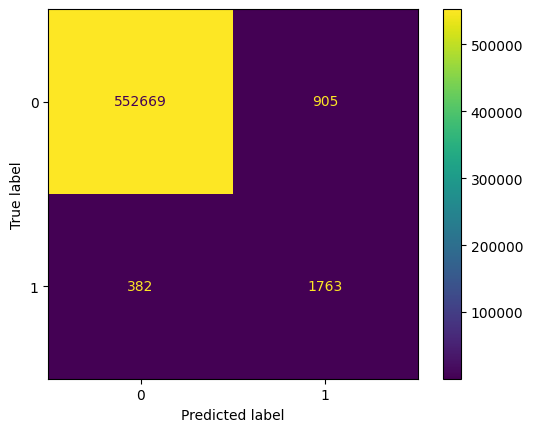

Sensibilità Costo FN - Baseline
              precision    recall  f1-score   support

       legit     0.9993    0.9984    0.9988    553574
       fraud     0.6608    0.8219    0.7326      2145

    accuracy                         0.9977    555719
   macro avg     0.8301    0.9101    0.8657    555719
weighted avg     0.9980    0.9977    0.9978    555719


Conteggio FN 382
Costo reale falsi negativi 55765.35


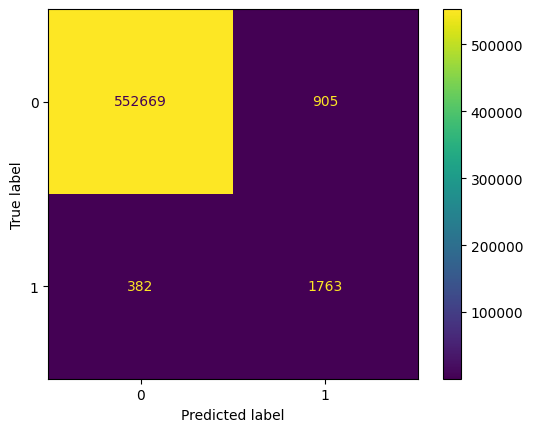

Sensibilità Costo FN - Medium-high
              precision    recall  f1-score   support

       legit     0.9993    0.9983    0.9988    553574
       fraud     0.6470    0.8247    0.7251      2145

    accuracy                         0.9976    555719
   macro avg     0.8232    0.9115    0.8620    555719
weighted avg     0.9980    0.9976    0.9977    555719


Conteggio FN 376
Costo reale falsi negativi 52931.23


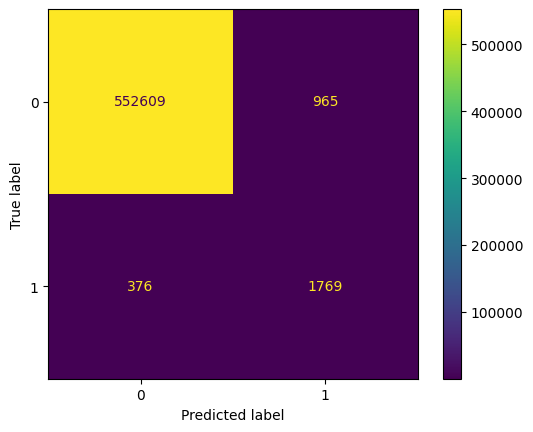

Sensibilità Costo FN - High
              precision    recall  f1-score   support

       legit     0.9993    0.9983    0.9988    553574
       fraud     0.6470    0.8247    0.7251      2145

    accuracy                         0.9976    555719
   macro avg     0.8232    0.9115    0.8620    555719
weighted avg     0.9980    0.9976    0.9977    555719


Conteggio FN 376
Costo reale falsi negativi 52931.23


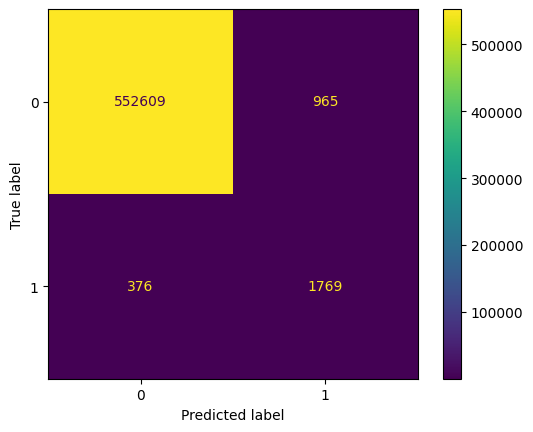


XGB - Test Analysis


,thresholds,costs,recall,precision,f1_score,pr_auc
Conservative,0.2316,123650,0.8219,0.6608,0.7326,0.8580
Baseline,0.2316,158030,0.8219,0.6608,0.7326,0.8580
Medium-high,0.2119,208930,0.8247,0.6470,0.7251,0.8580
High,0.2119,385650,0.8247,0.6470,0.7251,0.8580


In [318]:
#Pipeline Completa caricamento modello, preprocessing, predizioni e risultati (y già note)
#(funzioni utilizzate, caricacati già in celle precedenti, preprocessore e modello ricaricato all'interno della pipe)


X_y = df_test.copy()
y = X_y["is_fraud"].astype(int)
X = X_y.drop(columns=["is_fraud"]) #dataset per inferenza passato (senza le y)

def inference_pipeline(X, y_true):
    num_scaled_features=0

    proc_loader = joblib.load("preprocessor_v1.joblib")
    preprocessor = proc_loader["preprocessor"]
    num_scaled_features = proc_loader["num_scaled_features"]
    num_not_scaled = proc_loader["num_not_scaled"]

    if not isinstance(num_scaled_features, list):
        raise RuntimeError("Preprocessor not Loaded")

    X_proc = prep_data(X, preprocessor) #X processate per il modello

    xgb_ths_val = 0
    xgb_model, xgb_ths_val, xgb_costs_val, xgb_recalls_val, xgb_precisions_val, xgb_f1_scores_val, xgb_pr_aucs_val = load_model_ths("fraud_XGB_v2.joblib")

    if not isinstance(xgb_ths_val, dict):
        raise RuntimeError("XGB Model not Loaded")


    xgb_proba = xgb_model.predict_proba(X_proc)[:, 1]
    xgb_ths, xgb_costs, xgb_recalls, xgb_precisions, xgb_f1_scores, xgb_pr_aucs = th_for_cost_level_dict(y, xgb_proba, list(xgb_ths_val.values()))


    cm = {}
    xgb_pred = {}

    for label_cost, th_value in xgb_ths.items():
        xgb_pred[label_cost] = (xgb_proba >= th_value).astype(int)
        cm[label_cost] = confusion_matrix(y_true, xgb_pred[label_cost])

        pred = xgb_pred[label_cost]              # numpy array
        mask_fn = (y_true.values == 1) & (pred == 0)

        count = mask_fn.sum()
        tot_cost = X.loc[mask_fn, "amt"].sum()   # X deve essere ordinato prima come in questo caso

        print(f"Sensibilità Costo FN - {label_cost}\n{classification_report(y_true, xgb_pred[label_cost], target_names=["legit", "fraud"], digits=4)}\n")

        print("Conteggio FN", count)
        print("Costo reale falsi negativi", tot_cost)


        disp = ConfusionMatrixDisplay(confusion_matrix=cm[label_cost])
        disp.plot(values_format='d')  # 'd' per interi
        plt.show()

    xgb_test_analysis = pd.DataFrame(
        {
            "thresholds": xgb_ths,
            "costs": xgb_costs,
            "recall": xgb_recalls,
            "precision": xgb_precisions,
            "f1_score": xgb_f1_scores,
            "pr_auc": xgb_pr_aucs,
        }
    )
    print("\nXGB - Test Analysis") #com'è andata con il nuovo dataset di test
    display(xgb_test_analysis)

inference_pipeline(X, y)


**Pipeline di inferenza con etichette note (valutazione ex-post)**

Questa pipeline di inferenza consente una valutazione ex-post realistica delle performance del modello, confrontando il costo stimato in fase di validazione con il costo economico effettivamente osservato sui falsi negativi nel dataset di test.

I risultati mostrano che:

- Il modello XGBoost mantiene prestazioni stabili tra validation e test:
  - recall elevato e coerente (~82–83%),
  - precisione fraud ~65–66%,
  - PR-AUC pari a 0.858, in linea con le attese.
- Il numero di falsi negativi è contenuto (≈ 380 casi su oltre 550k transazioni).
- Il costo reale dei falsi negativi, calcolato come somma degli importi (amt) delle frodi mancate, risulta dell’ordine di 50–55k, significativamente inferiore rispetto ai costi proxy utilizzati in fase di ottimizzazione.

Un aspetto rilevante è che:
- Le soglie Conservative e Baseline producono risultati praticamente identici sul test set,
- mentre le soglie più aggressive (Medium-high / High) riducono marginalmente il costo reale dei FN a fronte di variazioni minime nelle metriche globali.

Nel complesso, questa analisi conferma che:

- l’approccio di ottimizzazione cost-sensitive basato su validation è robusto,
- le stime di costo sono coerenti e conservative,
- il modello selezionato potrebbe risultare operativamente affidabile in uno scenario reale, con le opportune tecniche atte a migliorare le performance nel tempo, come l'aggiornamento in tempo reale delle feature storiche e di novelty (si considerà in futuro l'implementazione di questa tecnica, soprattutto per mitigare l'effetto data drift dovuto al congelamento delle feature citate).

In [321]:
#Pipeline Completa caricamento modello, preprocessing, predizioni e azioni da compiere (y non note)
#(funzioni utilizzate, caricacati già in celle precedenti, preprocessore e modello ricaricato all'interno della pipe)

# Mode: ['Conservative', 'Baseline', 'Medium-high', 'High']

X_y = df_test.copy()
X = X_y.drop(columns=["is_fraud"]) #dataset per inferenza passato (senza le y)

X = X.sample(n=500, random_state=42) #in caso volessimo scegliere solo una o alcune righe

def inference_action_pipeline(X):

    VALID_MODES = {
        'conservative': 'Conservative',
        'baseline': 'Baseline',
        'medium-high': 'Medium-high',
        'high': 'High'
    }

    while True:
        user_input = input(
            "Seleziona la modalità "
            "(Conservative / Baseline / Medium-high / High): "
        ).strip().lower()

        if user_input in VALID_MODES:
            mode = VALID_MODES[user_input]
            break
        else:
            print("Modalità non valida. Riprova.\n")

    X = X.drop_duplicates().reset_index(drop=True) #necessario rimuovere i duplicati dal ds di test originale
    X = X.sort_values("trans_date_trans_time").reset_index(drop=True) #aggiunto già in questo step per averlo ordinato in analisi

    num_scaled_features=0

    proc_loader = joblib.load("preprocessor_v1.joblib")
    preprocessor = proc_loader["preprocessor"]
    num_scaled_features = proc_loader["num_scaled_features"]
    num_not_scaled = proc_loader["num_not_scaled"]

    if not isinstance(num_scaled_features, list):
        raise RuntimeError("Preprocessor not Loaded")

    X_proc = prep_data(X, preprocessor) #X processate per il modello

    xgb_ths_val = 0
    xgb_model, xgb_ths_val, xgb_costs_val, xgb_recalls_val, xgb_precisions_val, xgb_f1_scores_val, xgb_pr_aucs_val = load_model_ths("fraud_XGB_v2.joblib")

    if not isinstance(xgb_ths_val, dict):
        raise RuntimeError("XGB Model not Loaded")


    xgb_proba = xgb_model.predict_proba(X_proc)[:, 1]

    xgb_pred = (xgb_proba >= xgb_ths_val[mode]).astype(int)

    # print(xgb_pred.sum()) per check su tutto ds - ok

    for i, x in enumerate(xgb_pred):
        if x == 0:
            flag = "Transazione verificata"
        else:
            flag = "Operazione bloccata"

        X.loc[i, "Outcome"] = flag

    return X

In [320]:
X_result = inference_action_pipeline(X)
print(f"Sono state bloccate {X_result[X_result["Outcome"] == "Operazione bloccata"].shape[0]} transazioni su {X_result.shape[0]}")
display(X_result[X_result["Outcome"] == "Operazione bloccata"].head(X_result[X_result["Outcome"] == "Operazione bloccata"].shape[0]))

Seleziona la modalità (Conservative / Baseline / Medium-high / High):  conservative


Dataset - Inizio: 2020-06-21 19:23:19 - Fine: 2020-12-31 23:33:31
Sono state bloccate 2 transazioni su 500


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,Outcome
138,163504,2020-08-17 15:59:24,4755696071492,fraud_Auer-West,shopping_net,1037.3600,Robert,Evans,M,01892 Patricia Vista Apt. 828,...,32.9643,-96.6012,20328,Site engineer,1985-06-20,7d804f3f0e8d14f1792bf880be9657fc,1376755164,32.5831,-95.9661,Operazione bloccata
194,221271,2020-09-07 22:36:28,4623560839669,fraud_Kerluke Inc,misc_net,788.0700,Vincent,Waller,M,9379 Vanessa Run Apt. 400,...,42.2619,-94.5566,695,Administrator,1954-07-15,b45b5b66cdb3e0730438dc41e8799602,1378593388,42.4606,-94.0554,Operazione bloccata


**Pipeline di inferenza operativa (y non note)**

Questa pipeline rappresenta uno scenario di serving reale, in cui le etichette non sono disponibili e il modello viene utilizzato esclusivamente per supportare decisioni operative in tempo quasi-reale.

Le caratteristiche principali sono:
- Utilizzo del modello XGBoost finale e del preprocessing congelato dalla fase di addestramento/validazione.
- Selezione esplicita della modalità operativa (Conservative, Baseline, Medium-high, High), che consente di adattare il comportamento del sistema alle priorità di business (contenimento dei falsi positivi vs intercettazione delle frodi).

Traduzione diretta della predizione in azioni concrete:
- **Operazione bloccata** per transazioni ad alto rischio,
- **Transazione verificata** per il resto del flusso.

Nell’esempio mostrato (modalità Conservative), il sistema blocca solo 2 transazioni su 500, coerentemente con un’impostazione prudente che privilegia la riduzione dell’impatto sul cliente finale, riservando l’intervento ai casi con probabilità di frode molto elevata.

Questa pipeline evidenzia come il modello non sia solo uno strumento predittivo, ma un componente decisionale integrabile in un processo di monitoraggio antifrode, con soglie e comportamenti modulabili in funzione del contesto operativo e del profilo di rischio accettabile.

## Limitazioni e sviluppi futuri
### Limitazioni

**Dataset simulato**

Il dataset utilizzato, pur essendo realistico nella struttura, rimane una simulazione. Alcune dinamiche tipiche dei sistemi antifrode reali (ad esempio concept drift, feedback loop operativi, interventi manuali) non sono completamente rappresentate.

**Congelamento delle feature storiche in test**

Per garantire coerenza metodologica e una valutazione imparziale, le feature storiche sono state mantenute congelate allo stato di fine validation.
In un sistema reale, alcune di queste feature (ad esempio recency o nuovi merchant) potrebbero essere aggiornate dinamicamente, richiedendo una riallocazione periodica delle soglie decisionali.

**Soglie ottimizzate offline**

Le soglie di decisione sono state ottimizzate su validation e applicate in test. In produzione, la distribuzione delle probabilità può evolvere nel tempo, rendendo necessaria una ricalibrazione continua.

**Costo di errore approssimato**

La funzione di costo utilizza una parametrizzazione semplificata (costo medio per FN e FP). Nella pratica, il costo reale dipende anche da fattori contestuali (importo, cliente, canale, storico).

### Sviluppi futuri

**Gestione del concept drift**

Introduzione di meccanismi di monitoraggio della distribuzione delle feature e delle probabilità predette, con alert automatici e retraining periodico.

**Ricalibrazione dinamica delle soglie**

Separazione tra modello predittivo e layer decisionale, con soglie adattive basate su KPI operativi (tasso di blocco, costo medio, capacità del team antifrode).

**Ensemble e strategie di cascading**

Utilizzo combinato dei modelli (ad esempio LR → RF → XGB) in pipeline sequenziali per ridurre il carico operativo mantenendo alta la recall sulle frodi più critiche.

**Integrazione di feedback umano**

Utilizzo delle decisioni manuali come segnale di apprendimento per migliorare il modello e le feature storiche in modo supervisionato.

**Explainability operativa**

Integrazione delle spiegazioni SHAP a livello di singola transazione per supportare gli operatori antifrode nella revisione dei casi borderline.

**Tecniche di upsampling guidate dal dominio**

Come suggerito in letteratura, l’uso di tecniche di upsampling (ad esempio SMOTE e sue varianti) potrebbe essere esplorato per 
mitigare ulteriormente lo sbilanciamento delle classi.
In un contesto di fraud detection, tali tecniche dovrebbero essere applicate con cautela e preferibilmente in combinazione con vincoli temporali e di business, per evitare la generazione di pattern fraudolenti poco realistici o leakage indiretto. Per risolvere anche questo tipo di problemi sono state sviluppate tecniche avanzate, come l'approccio Hybrid GAN–Transformer (https://arxiv.org/pdf/2509.19032), per la creazione di esempi di classe fraudolenta, molto più vicini alla realtà di quelli ottenuti dalle tecniche tradizionali.